# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Please read the instructions carefully before starting the project.**

This is a commented Python Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_____' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_____' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same. Any mathematical or computational details which are a graded part of the project can be included in the Appendix section of the presentation.

# **Installing and Importing the necessary libraries**

In [4]:
#Installing the libraries with the specified versions
#!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [5]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

import warnings
warnings.filterwarnings("ignore")

# **Loading the dataset**

In [6]:
# Uncomment the below snippet of code if the drive needs to be mounted
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
kart = pd.read_csv("/content/drive/MyDrive/PGP-AIML/M7: Model Deployment/Project/SuperKart.csv")

In [8]:
# copying data to another variable to avoid any changes to original data
data = kart.copy()

# **Data Overview**

## View the first and last 5 rows of the dataset

In [9]:
data.head(5)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [10]:
data.tail(5)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


## Understand the shape of the dataset

In [11]:
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")

There are 8763 rows and 12 columns.


## Check the data types of the columns for the dataset

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


## Statistical summary of the data

**Let's check the statistical summary of the data.**

In [13]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD306,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observation:**

 - Fruits and Vegetables are the top product categories, with most products having low sugar content.
 - Product prices range from $31 to $266, with an average price of approximately $147.
 - The mean and median prices are closely aligned, suggesting a roughly normal price distribution with no significant skew.
 - Most stores are medium-sized, with Supermarket Type 2 being the most common store format.
 - Tier 2 cities have the highest concentration of stores across all city tiers.
 - Store establishment years span from 1987 to 2009, representing over two decades of retail expansion.


## Checking for duplicate values

In [14]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

- There are no duplicate values in the data.

## Checking for missing values

In [15]:
# checking for missing values in the data
data.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


- There are no missing values in the daa.

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [16]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### **Product_Weight**

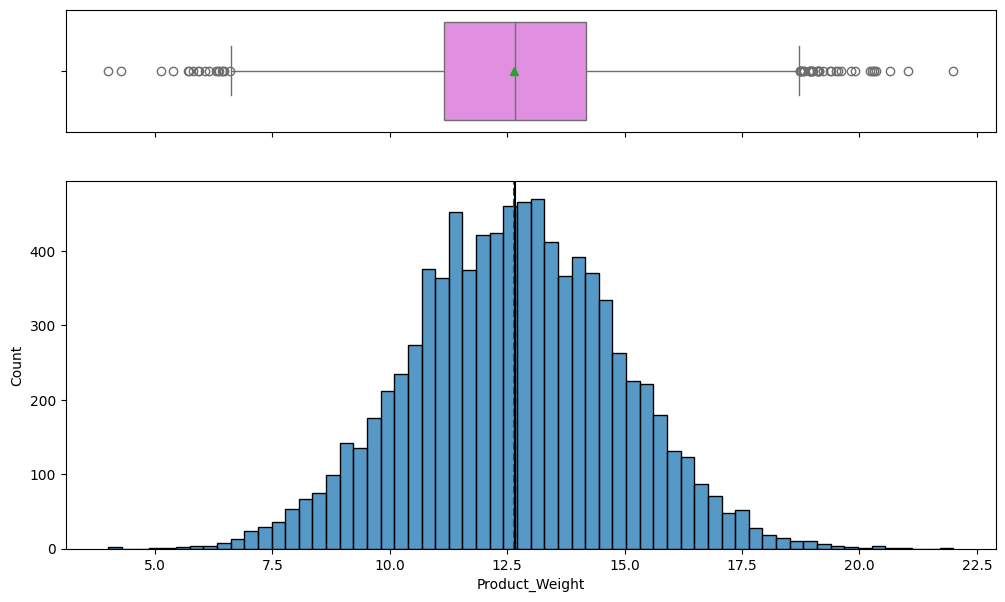

In [17]:
histogram_boxplot(data, "Product_Weight")

- Product weight histogram shows fairly normal distribution with no significant skew.
- The data has outliers at both lower and higher ranges.

### **Product_Allocated_Area**

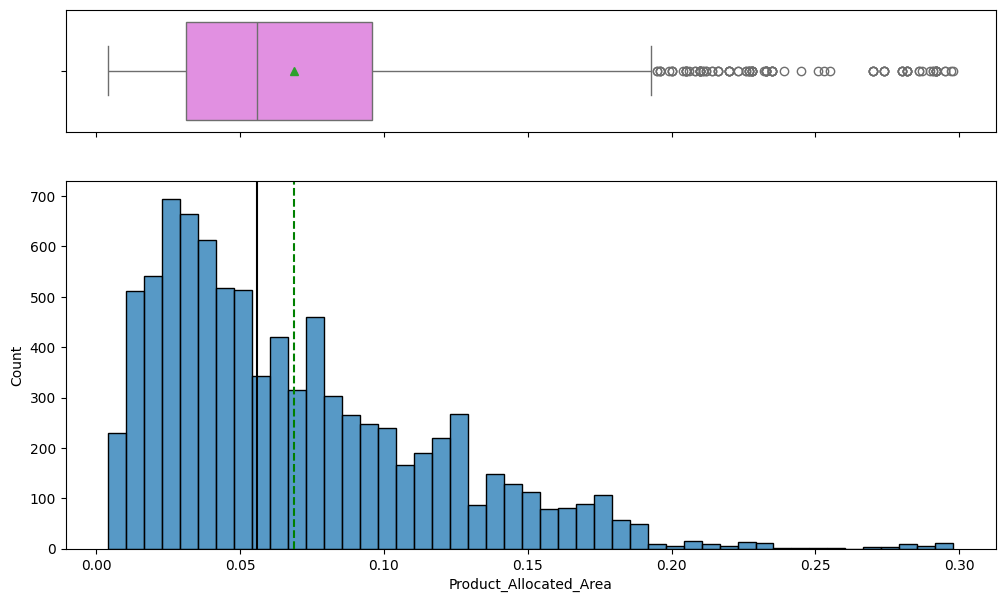

In [18]:
histogram_boxplot(data, "Product_Allocated_Area")

- Product allocated area histogram shows a right-skewed distribution, indicating that most products occupy a smaller area, with only a few products having significantly larger allocations — which is expected.

### **Product_MRP**

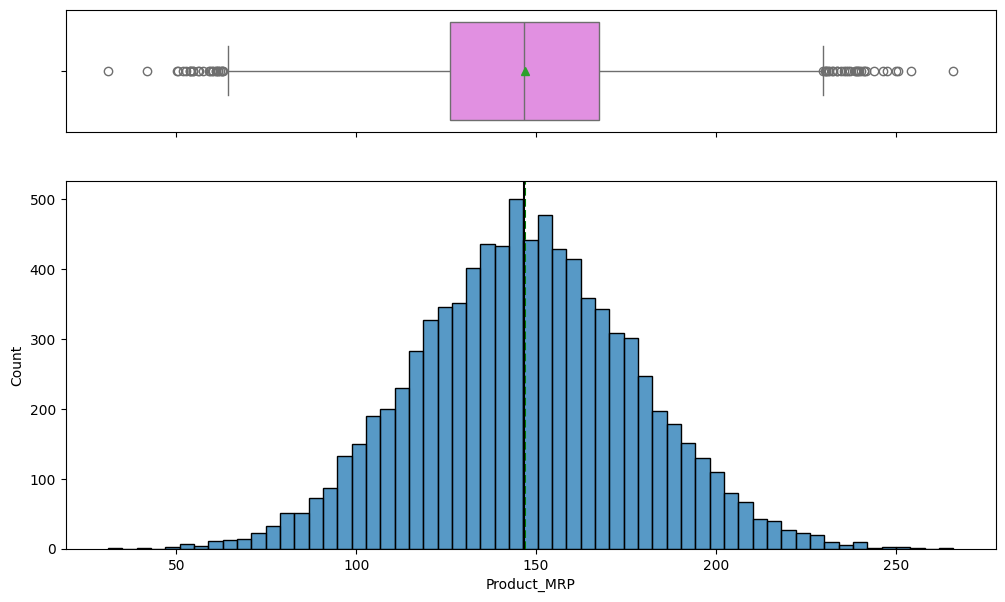

In [19]:
histogram_boxplot(data, "Product_MRP")

- Product MRP histogram shows a near-perfect bell shape, indicating a normally distributed pricing structure.
- The majority of products are priced between $100 and $200, representing the core price range.
- While outliers are present, no treatment is necessary as the varying price points reflect natural market pricing.

### **Product_Store_Sales_Total**

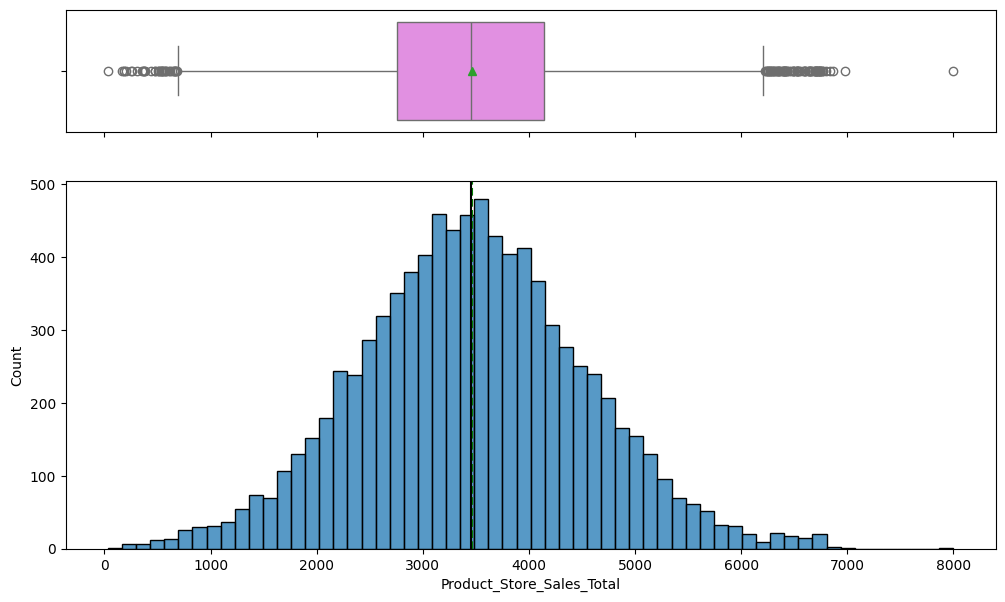

In [20]:
histogram_boxplot(data, "Product_Store_Sales_Total")

- Product Store Sales histogram shows a near-perfect bell shape, indicating a normally distributed sales pattern.
- The average product store sales total is around \$3,500, with most values falling between \$2,000 and $5,000.
- A few outliers are present, but no treatment is required as they reflect natural sales variability.

In [21]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### **Product_Sugar_Content**

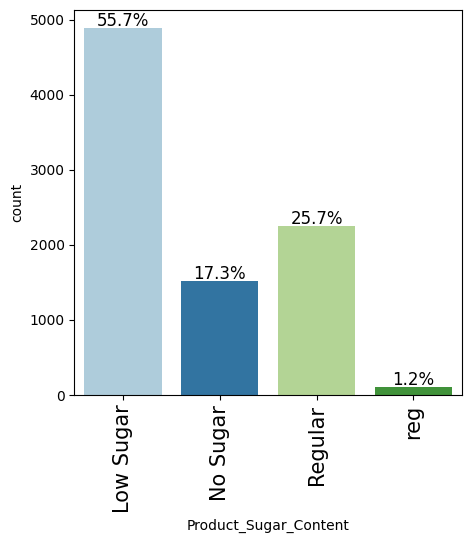

In [22]:
labeled_barplot(data, "Product_Sugar_Content", perc=True)

- Low Sugar dominates at 55.7%, making it the most common sugar content category by a wide margin.
- Regular comes in second at 25.7%, followed by No Sugar at 17.3%.
- The "reg" category accounts for only 1.2% — this looks like a data quality issue, likely a duplicate of "Regular" that needs to be cleaned up.

### **Product_Type**

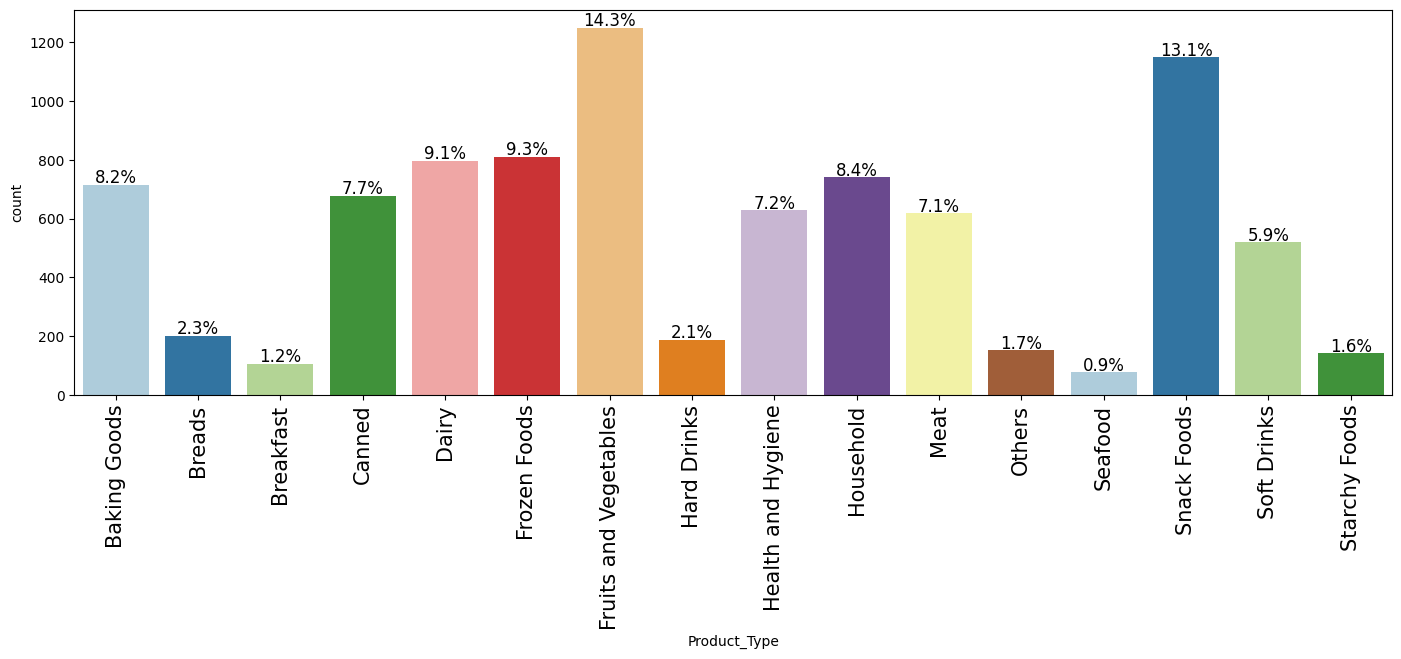

In [23]:
labeled_barplot(data, "Product_Type", perc=True) #plot the labelled barplot of Product_Type with the percentages being displayed

- Fruits and Vegetables is the most common product type at 14.3%, followed closely by Snack Foods at 13.1%.
- Frozen Foods (9.3%) and Dairy (9.1%) round out the top four categories.
- Seafood (0.9%), Starchy Foods (1.6%), and Others (1.7%) are the least represented categories.
- Overall, the distribution is fairly spread across categories, with no single type overwhelmingly dominating the dataset.

### **Store_Id**

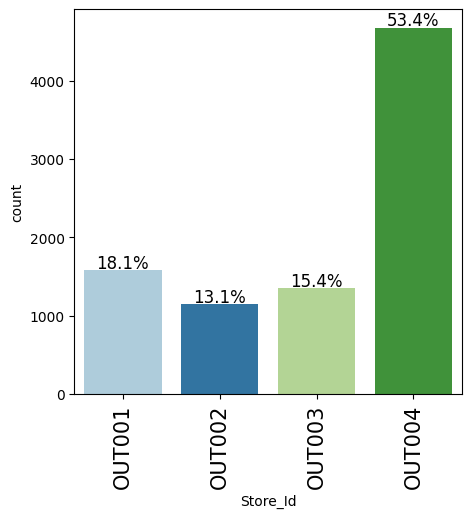

In [24]:
labeled_barplot(data, "Store_Id", perc=True) #Plot the labelled barplot of Store_Id with the percentages being displayed

- OUT004 accounts for over half the dataset at 53.4%, while the remaining three stores — OUT001 (18.1%), OUT003 (15.4%), and OUT002 (13.1%) — are fairly evenly distributed.
- This heavy concentration in OUT004 introduces a store bias in the data, which could influence model predictions if store identity is a contributing factor.

### **Store_Size**

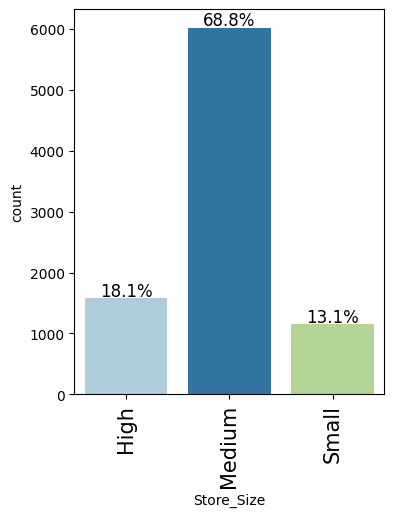

In [25]:
labeled_barplot(data, "Store_Size", perc=True) #Plot the labelled barplot of Store_Size with the percentages being displayed

- Medium-sized stores dominate the dataset at 69%, followed by High at 18.1% and Small at 13.1%, indicating an uneven representation across store sizes.

### **Store_Location_City_Type**

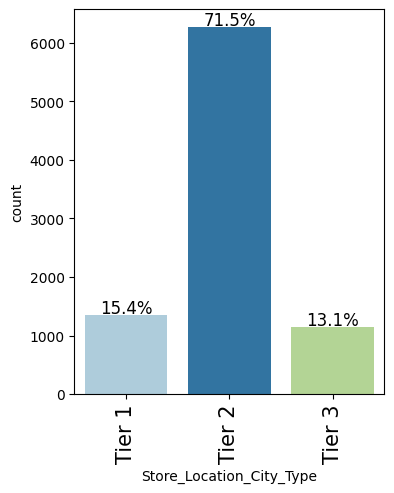

In [26]:
labeled_barplot(data, "Store_Location_City_Type", perc=True) #Plot the labelled barplot of Store_Location_City_Type with the percentages being displayed

- pTier 2 cities overwhelmingly dominate the dataset at 71.5%, while Tier 1 (15.4%) and Tier 3 (13.1%) are comparably small and close to each other.
- Similar to store size, this heavy skew toward Tier 2 cities indicates an uneven representation across city types, which could introduce location bias in the model.

### **Store_Type**

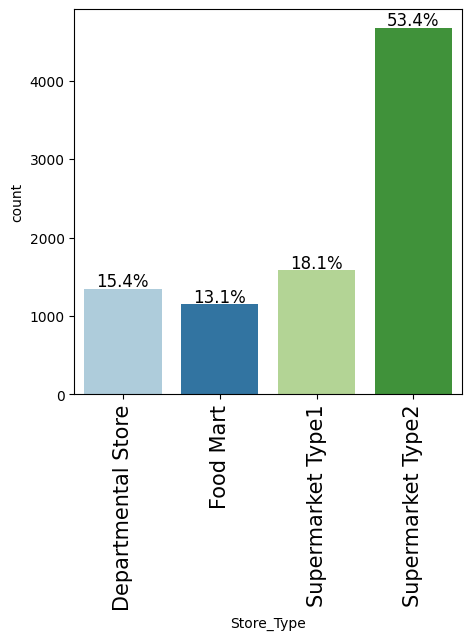

In [27]:
labeled_barplot(data, "Store_Type", perc=True) #Plot the labelled barplot of Store_Type with the percentages being displayed

- Supermarket Type 2 dominates the dataset at 53%, followed by Supermarket Type 1 (18.1%), Departmental Stores (15.4%), and Food Marts (13.1%), showing a clear imbalance across store types.

## Bivariate Analysis

### **Correlation matrix**

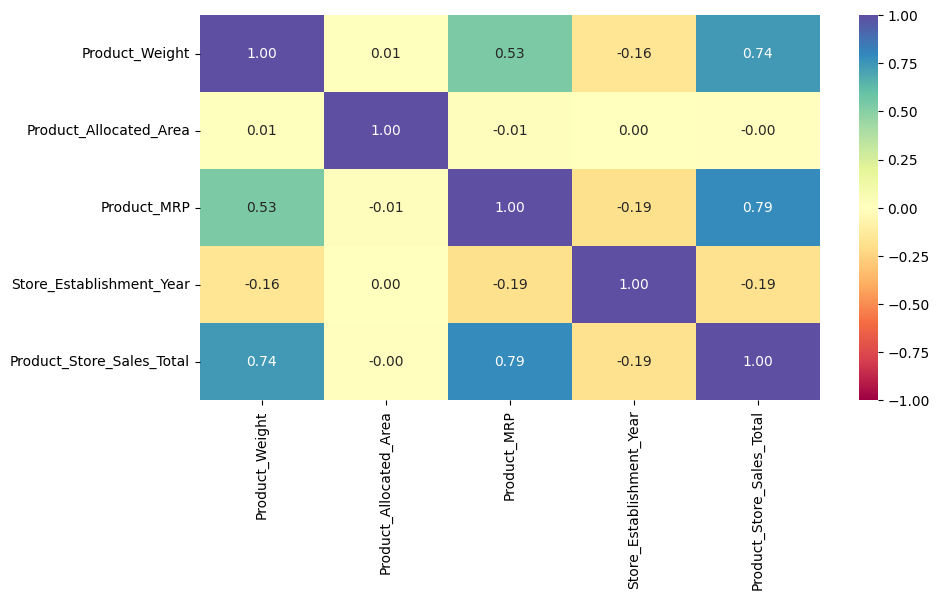

In [28]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

- Product Store sales show a strong positive correlation with both Product Weight and Product MRP.
- Product MRP positively correlates with Product weight, suggesting that heavier products tend to command higher prices.
- Store establishment year shows a weak negative correlation with Product Store sales, Product weight, and MRP, implying that older stores may slightly underperform newer ones across these metrics.

### **Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the numeric columns**

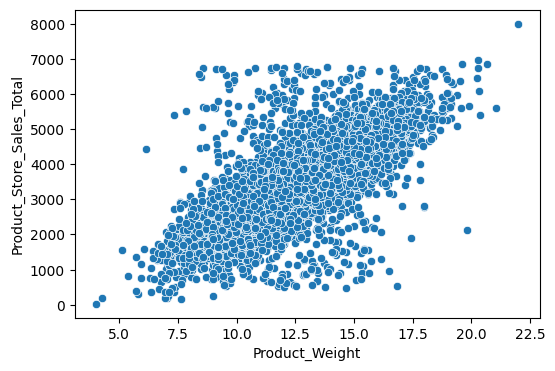

In [29]:
plt.figure(figsize=[6, 4])
sns.scatterplot(x=data.Product_Weight, y=data.Product_Store_Sales_Total)
plt.show()

- Store sales show a positive correlation with product weight, suggesting that heavier products tend to generate more sales.

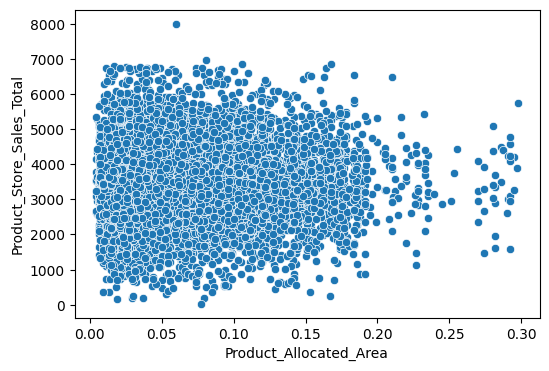

In [30]:
plt.figure(figsize=[6, 4])
sns.scatterplot(data=data, x='Product_Allocated_Area', y='Product_Store_Sales_Total') #Scatterplot of Product_Allocated_Area and Product_Store_Sales_Total
plt.show()

- There is no clear correlation between Product Store sales and Product Allocated Area.

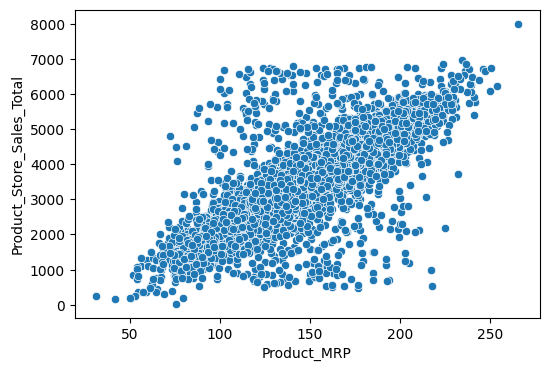

In [31]:
plt.figure(figsize=[6, 4])
sns.scatterplot(x=data.Product_MRP, y=data.Product_Store_Sales_Total) #Scatterplot of Product_MRP and Product_Store_Sales_Total
plt.show()

- Store sales tend to be higher for products with a greater MRP, pointing to a positive correlation between the two.

### **Let us see from which product type the company is generating most of the revenue**

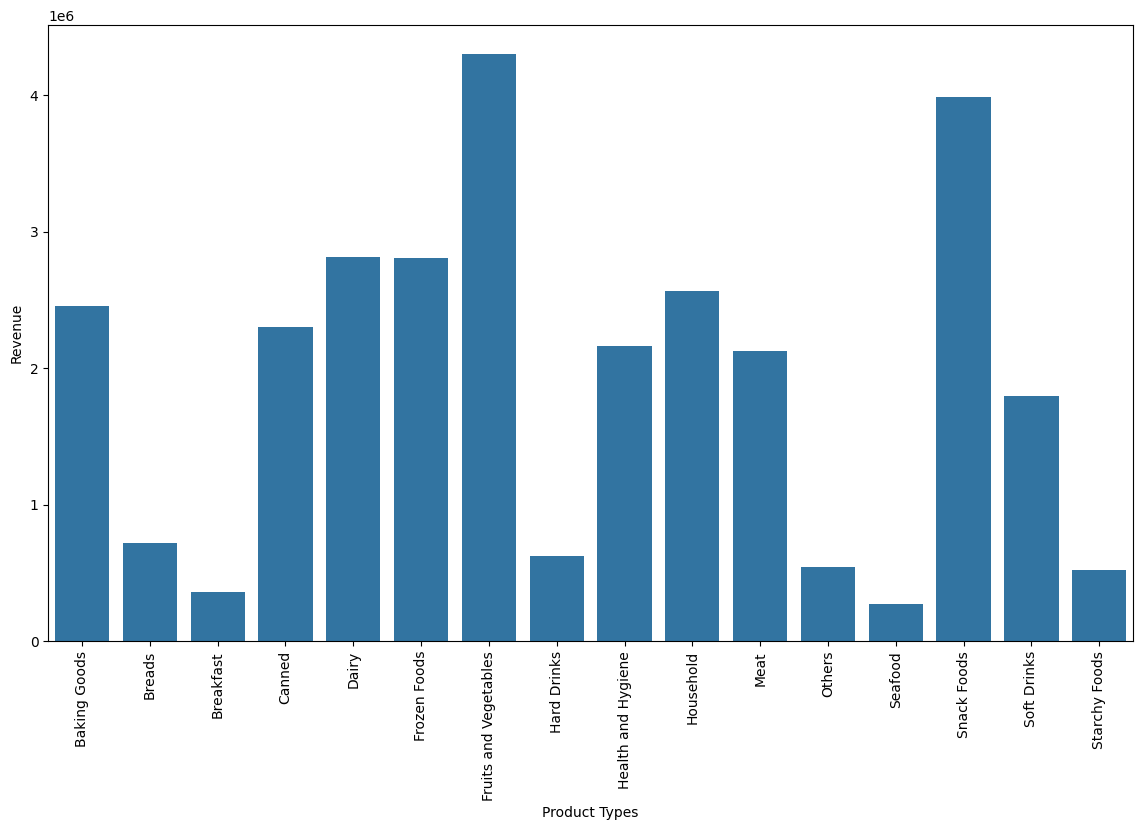

In [32]:
df_revenue1 = data.groupby(["Product_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
a = sns.barplot(x=df_revenue1.Product_Type, y=df_revenue1.Product_Store_Sales_Total)
a.set_xlabel("Product Types")
a.set_ylabel("Revenue")
plt.show()

- Fruits & Vegetables and Snack Foods are the top revenue-generating categories.
- Dairy, Frozen Foods, Baking Goods, Canned, and Household products generate broadly similar revenues.
- Seafood, Breakfast, Starchy Foods, Hard Drinks, and other product types trail behind with comparatively lower revenues.

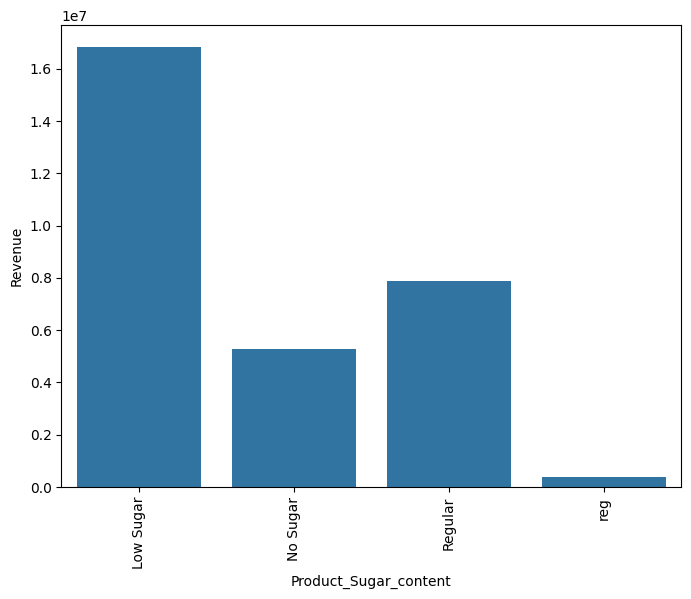

In [33]:
df_revenue2 = data.groupby(["Product_Sugar_Content"], as_index=False)[
    "Product_Store_Sales_Total"].sum()  #Perform a groupby on Product_Sugar_Content and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
b = sns.barplot(
    x=df_revenue2.Product_Sugar_Content, y=df_revenue2.Product_Store_Sales_Total
)
b.set_xlabel("Product_Sugar_content")
b.set_ylabel("Revenue")
plt.show()

- Low Sugar products lead in revenue generation, followed by Regular and No Sugar variants.

### **Let us see from which type of stores and locations the revenue generation is more**.

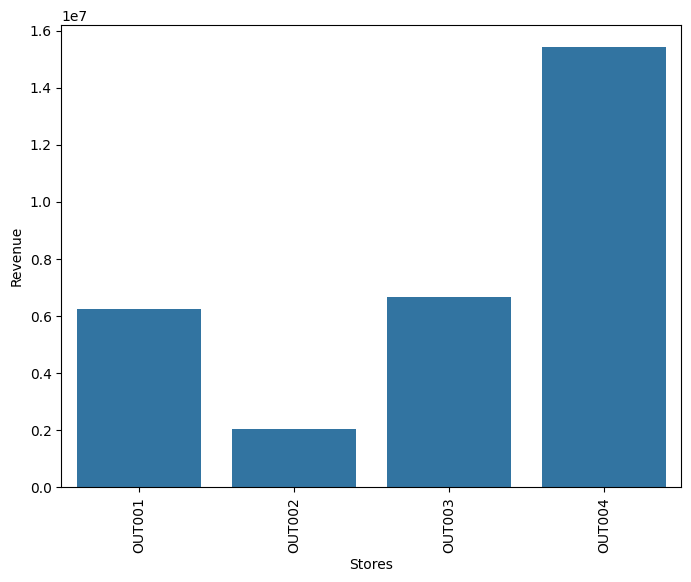

In [34]:
df_store_revenue = data.groupby(["Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"].sum() #Perform a groupby on Store_Id and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
r = sns.barplot(
    x=df_store_revenue.Store_Id, y=df_store_revenue.Product_Store_Sales_Total
)
r.set_xlabel("Stores")
r.set_ylabel("Revenue")
plt.show()

- Store OUT004 is the highest revenue-generating store, followed by OUT003, OUT001, and OUT002.

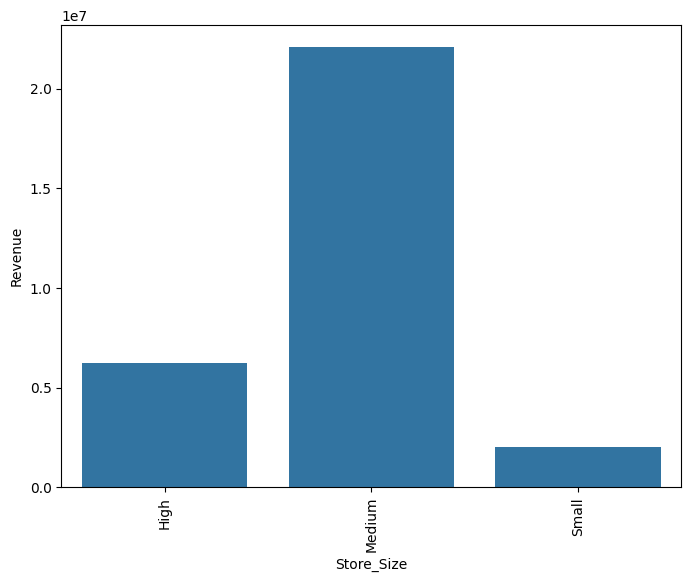

In [35]:
df_revenue3 = data.groupby(["Store_Size"], as_index=False)[
    "Product_Store_Sales_Total"
].sum() #Groupby on Store_Size and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
c = sns.barplot(x=df_revenue3.Store_Size, y=df_revenue3.Product_Store_Sales_Total)
c.set_xlabel("Store_Size")
c.set_ylabel("Revenue")
plt.show()

- Medium-sized stores lead in revenue generation, outperforming both Small and Large stores, suggesting an optimal store size sweet spot for sales performance.

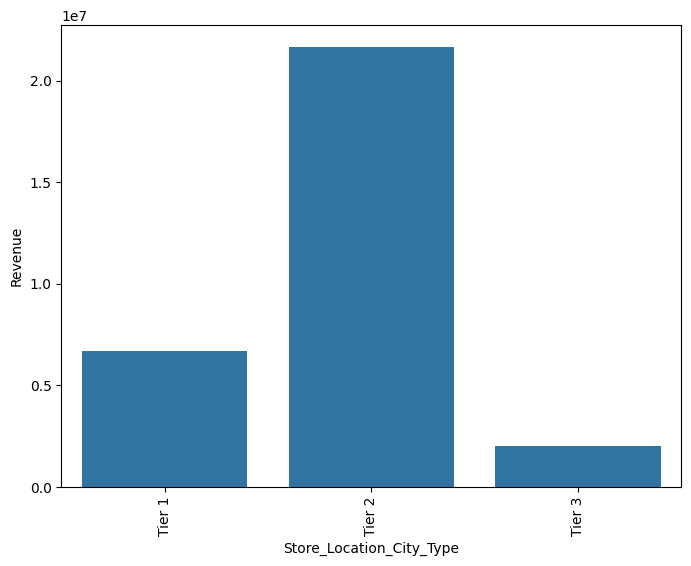

In [36]:
df_revenue4 = data.groupby(["Store_Location_City_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum() #Groupby on Store_Location_City_Type and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
d = sns.barplot(
    x=df_revenue4.Store_Location_City_Type, y=df_revenue4.Product_Store_Sales_Total
)
d.set_xlabel("Store_Location_City_Type")
d.set_ylabel("Revenue")
plt.show()

- Tier 2 city stores generate the highest revenues, surpassing both Tier 1 and Tier 3 counterparts, which may reflect a stronger consumer demand or less market saturation in mid-sized cities.


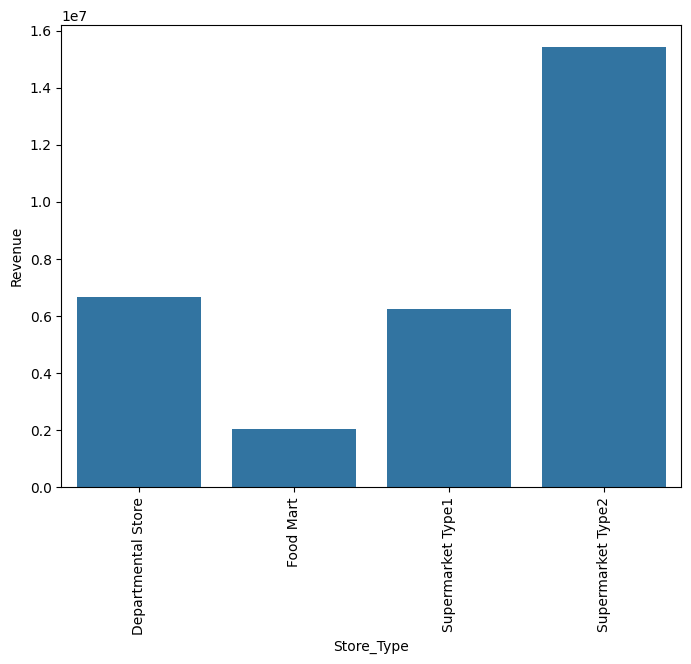

In [37]:
df_revenue5 = data.groupby(["Store_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum() #Groupby on Store_Type and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
e = sns.barplot(x=df_revenue5.Store_Type, y=df_revenue5.Product_Store_Sales_Total)
e.set_xlabel("Store_Type")
e.set_ylabel("Revenue")
plt.show()

- Type 2 Supermarkets are the top revenue generators, while Food marts trail significantly, reinforcing the notion that larger store formats tend to drive higher sales volumes.
- Type 1 and Departmental stores perform comparably, generating similar revenue levels despite potentially differing in size and product range.

### **Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the other categorical columns.**


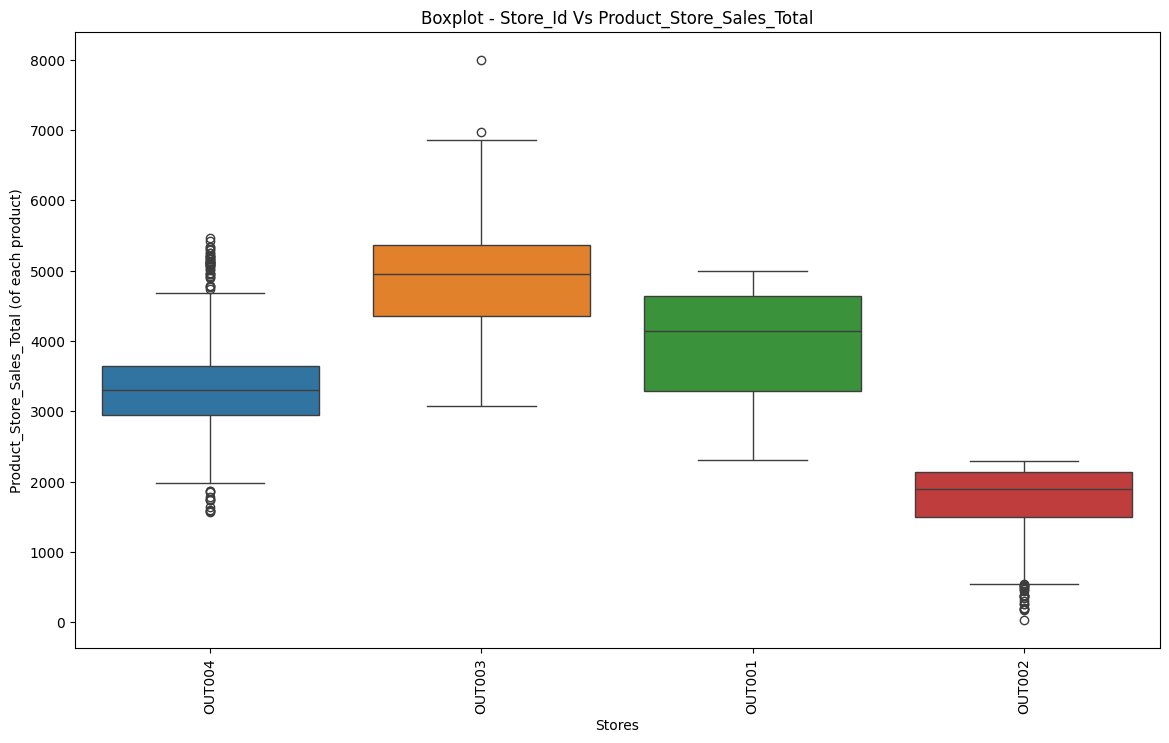

In [38]:
plt.figure(figsize=[14, 8])
sns.boxplot(data=data, x="Store_Id", y="Product_Store_Sales_Total", hue = "Store_Id")
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

- Box plot by Store Id suggests that OUT003 has the largest inter quartile range with a median of aroound $5000, indicating a strong consistent performance.
- OUT004 and OUT002 have lot of outliers which needs further investigation.

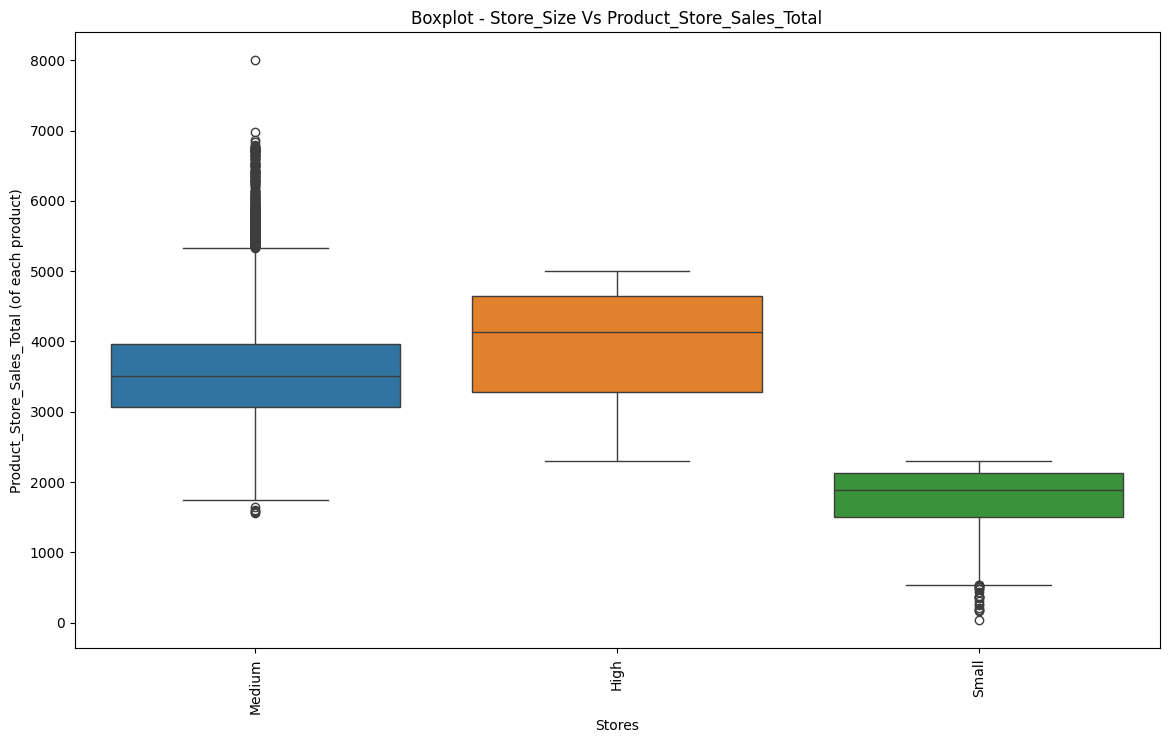

In [39]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Store_Size", y = "Product_Store_Sales_Total", hue = "Store_Size") #Boxplot with x as Store_Size , y as Product_Store_Sales_Total and hue as Store_Size
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Size Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

- High stores have wider inter quartile range, with no outliers.
- Medium and small size stores have small iqr range and lot of outliers.

### **Let's now try to find out some relationship between the other columns**

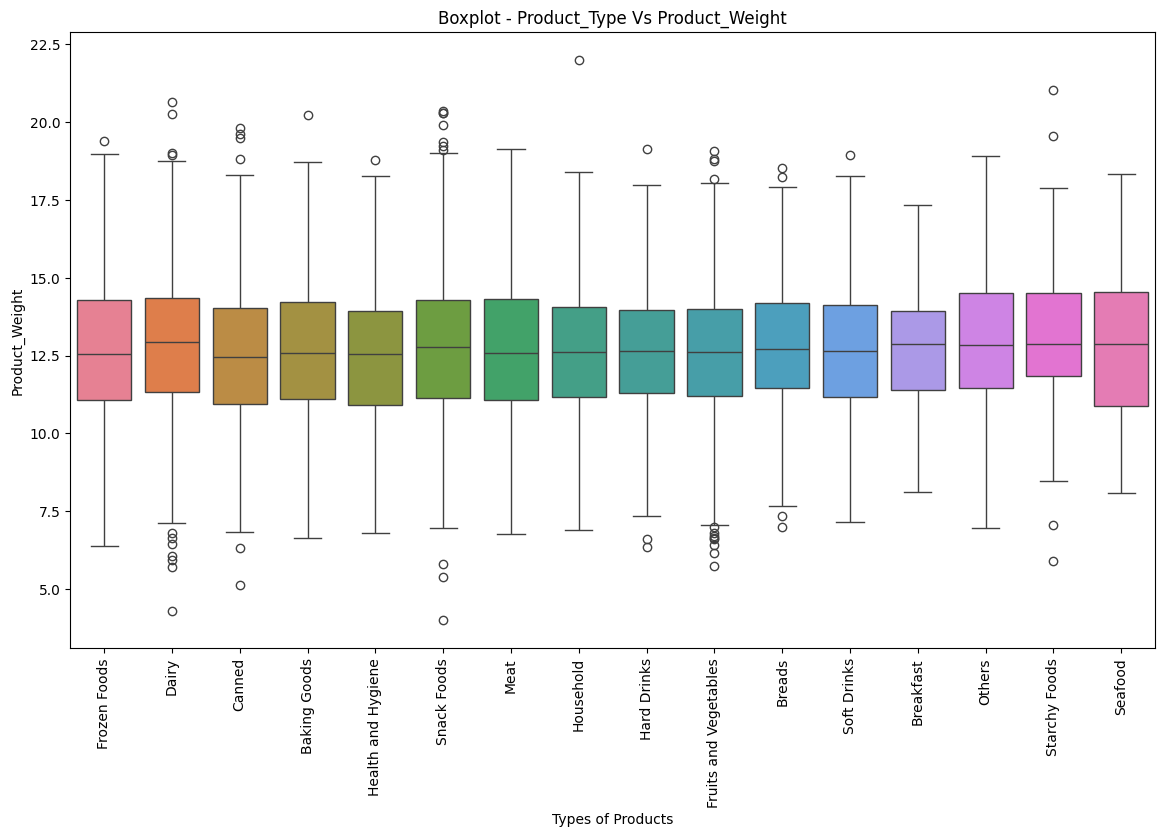

In [40]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_Weight", hue = "Product_Type") #Boxplot with x as Product_Type , y as Product_Weight and hue as Product_Type
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_Weight")
plt.xlabel("Types of Products")
plt.ylabel("Product_Weight")
plt.show()

### **Let's find out whether there is some relationship between the weight of the product and its sugar content**

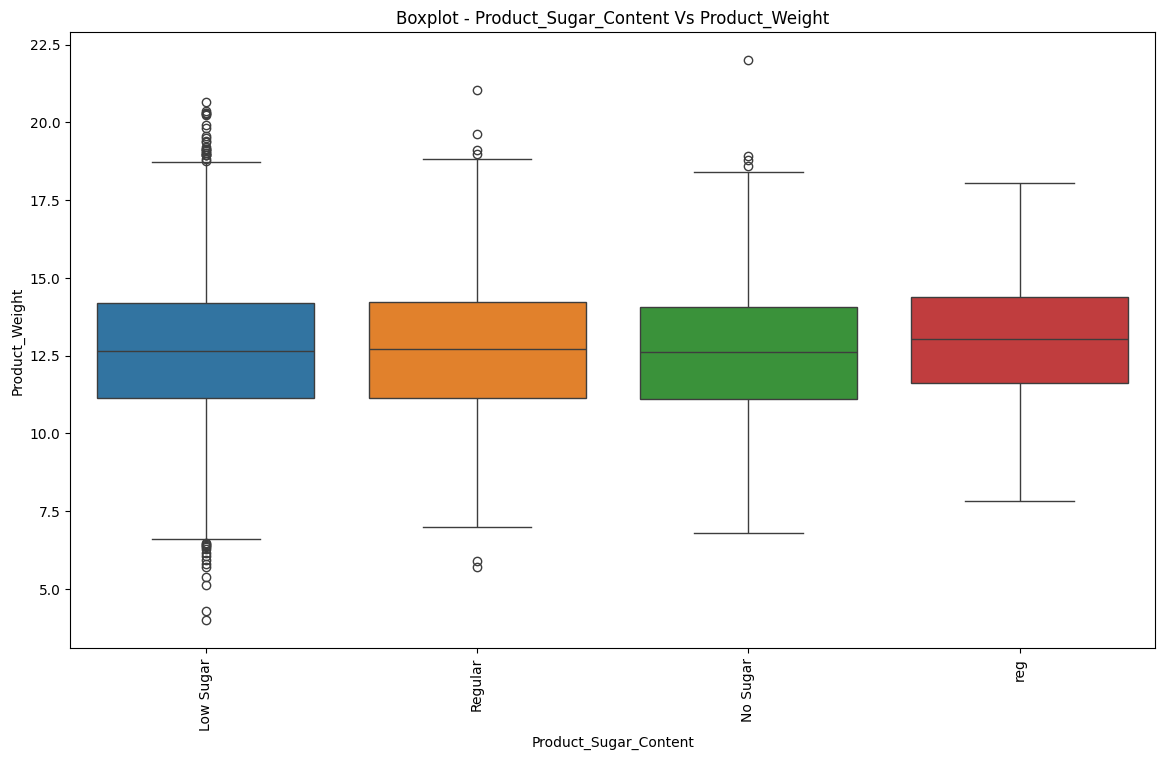

In [41]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Sugar_Content", y = "Product_Weight", hue = "Product_Sugar_Content") #Boxplot with x as Product_Sugar_Content , y as Product_Weight and hue as Product_Sugar_Content
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Sugar_Content Vs Product_Weight")
plt.xlabel("Product_Sugar_Content")
plt.ylabel("Product_Weight")
plt.show()

### **Let's analyze the sugar content of different product types**

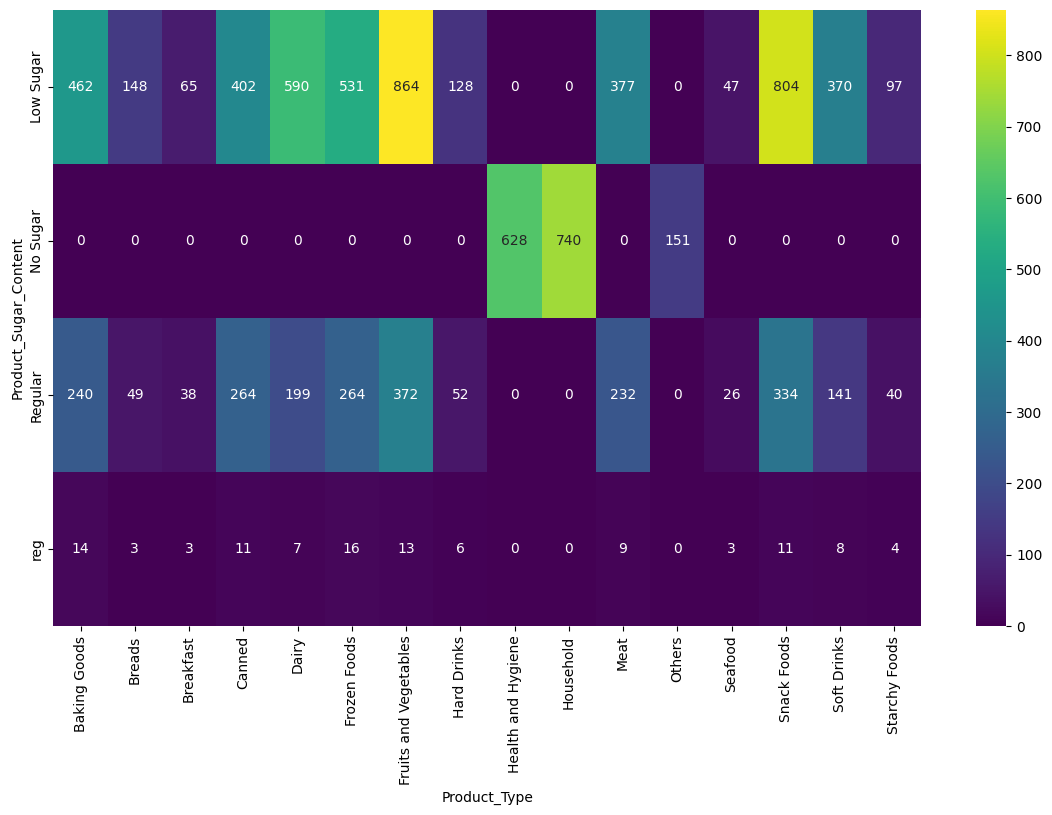

In [42]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Product_Sugar_Content"], data["Product_Type"]),
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Product_Sugar_Content")
plt.xlabel("Product_Type")
plt.show()

### **Let's find out how many items of each product type has been sold in each of the stores**

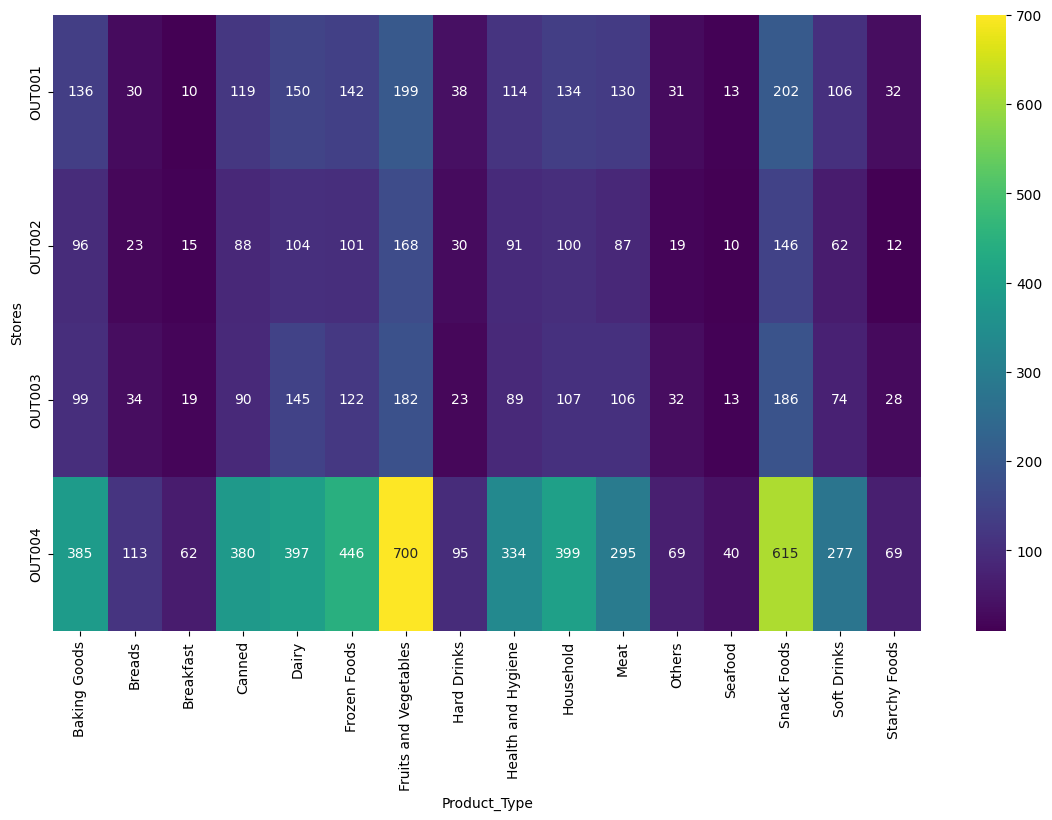

In [43]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Store_Id"], data["Product_Type"]), #Crosstab operation between Store_Id and Product_Type
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Stores")
plt.xlabel("Product_Type")
plt.show()

### **Different product types have different prices. Let's analyze the trend.**

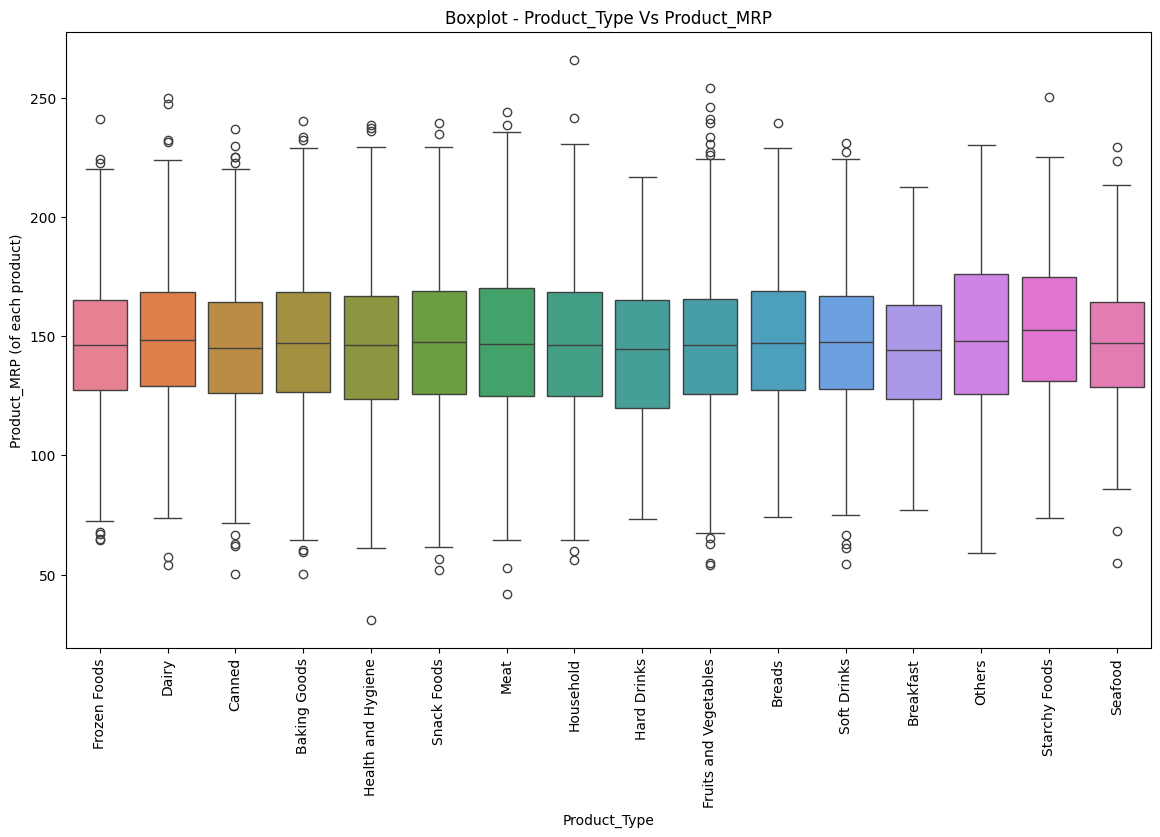

In [44]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_MRP", hue = "Product_Type") #Boxplot with x as Product_Type , y as Product_MRP and hue as Product_Type
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_MRP")
plt.xlabel("Product_Type")
plt.ylabel("Product_MRP (of each product)")
plt.show()

### **Let's find out how the Product_MRP varies with the different stores**

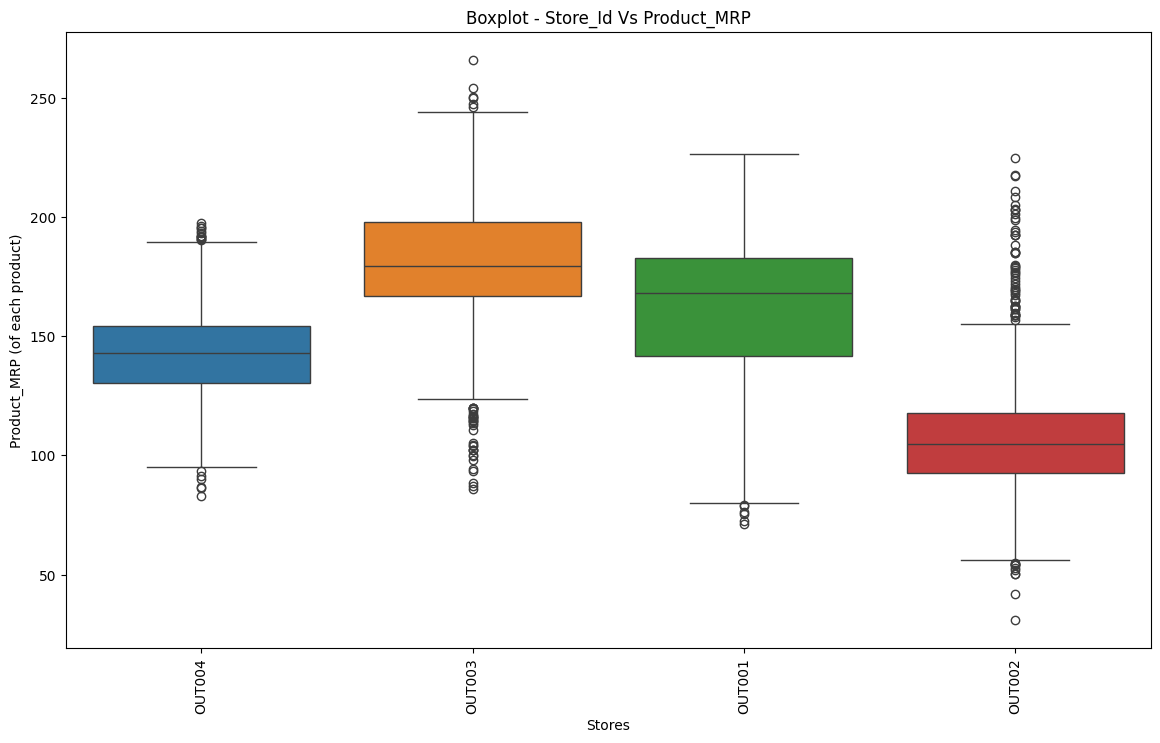

In [45]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Store_Id", y = "Product_MRP", hue = "Store_Id") #Boxplot with x as Store_Id , y as Product_MRP and hue as Store_Id
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_MRP")
plt.xlabel("Stores")
plt.ylabel("Product_MRP (of each product)")
plt.show()

### **Let's delve deeper and do a detailed analysis of each of the stores**.

#### OUT001

In [46]:
data.loc[data["Store_Id"] == "OUT001"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1586,1586,NC7187,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1586.0,NaN,NaN,NaN,13.458865,2.064975,6.16,12.0525,13.96,14.95,17.97
Product_Sugar_Content,1586,4,Low Sugar,845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1586.0,NaN,NaN,NaN,0.068768,0.047131,0.004,0.033,0.0565,0.094,0.295
Product_Type,1586,16,Snack Foods,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1586.0,NaN,NaN,NaN,160.514054,30.359059,71.35,141.72,168.32,182.9375,226.59
Store_Id,1586,1,OUT001,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1586.0,NaN,NaN,NaN,1987.0,0.0,1987.0,1987.0,1987.0,1987.0,1987.0
Store_Size,1586,1,High,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1586,1,Tier 2,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT001 is a store of Supermarket Type 1 which is located in a Tier 2 city and has store size as high. It was established in 1987.
- OUT001 has sold products whose MRP range from 71 to 227.
- Snack Foods have been sold the highest number of times in OUT001.
- The revenue generated from each product at OUT001 ranges from 2300 to 5000.

In [47]:
data.loc[data["Store_Id"] == "OUT001", "Product_Store_Sales_Total"].sum()

np.float64(6223113.18)

-OUT001 has generated total revenue of $6,223,113 from the sales of goods.

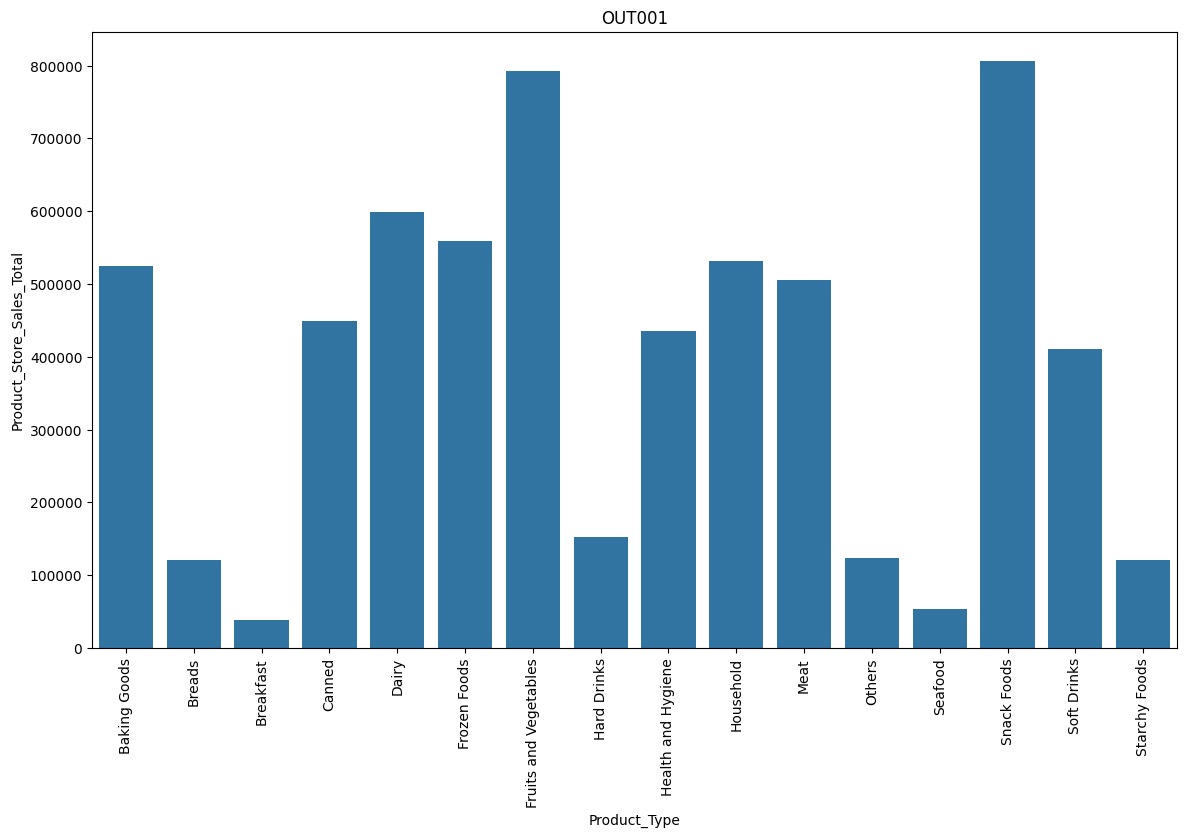

In [48]:
df_OUT001 = (
    data.loc[data["Store_Id"] == "OUT001"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT001")
sns.barplot(x=df_OUT001.Product_Type, y=df_OUT001.Product_Store_Sales_Total)
plt.show()

- OUT001 has generated the highest revenue from the sale of fruits and vegetables and snack foods. Both the categories have contributed around 800000 each.

#### OUT002

In [49]:
data.loc[data["Store_Id"] == "OUT002"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1152,1152,FD2446,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1152.0,NaN,NaN,NaN,9.911241,1.799846,4.0,8.7675,9.795,10.89,19.82
Product_Sugar_Content,1152,4,Low Sugar,658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1152.0,NaN,NaN,NaN,0.067747,0.047567,0.006,0.031,0.0545,0.09525,0.292
Product_Type,1152,16,Fruits and Vegetables,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1152.0,NaN,NaN,NaN,107.080634,24.912333,31.0,92.8275,104.675,117.8175,224.93
Store_Id,1152,1,OUT002,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1152.0,NaN,NaN,NaN,1998.0,0.0,1998.0,1998.0,1998.0,1998.0,1998.0
Store_Size,1152,1,Small,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1152,1,Tier 3,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT002 is a food mart which is located in a Tier 3 city and has store size as small. It was established in 1998.
- OUT002 has sold products whose MRP range from 31 to 225.
- Fruits and vegetables have been sold the highest number of times in OUT002.
- The revenue generated from each product at OUT002 ranges from 33 to 2300.

In [50]:
data.loc[data["Store_Id"] == "OUT002", "Product_Store_Sales_Total"].sum()

np.float64(2030909.72)

- OUT002 has generated total revenue of $2,030,910 from the sales of goods.

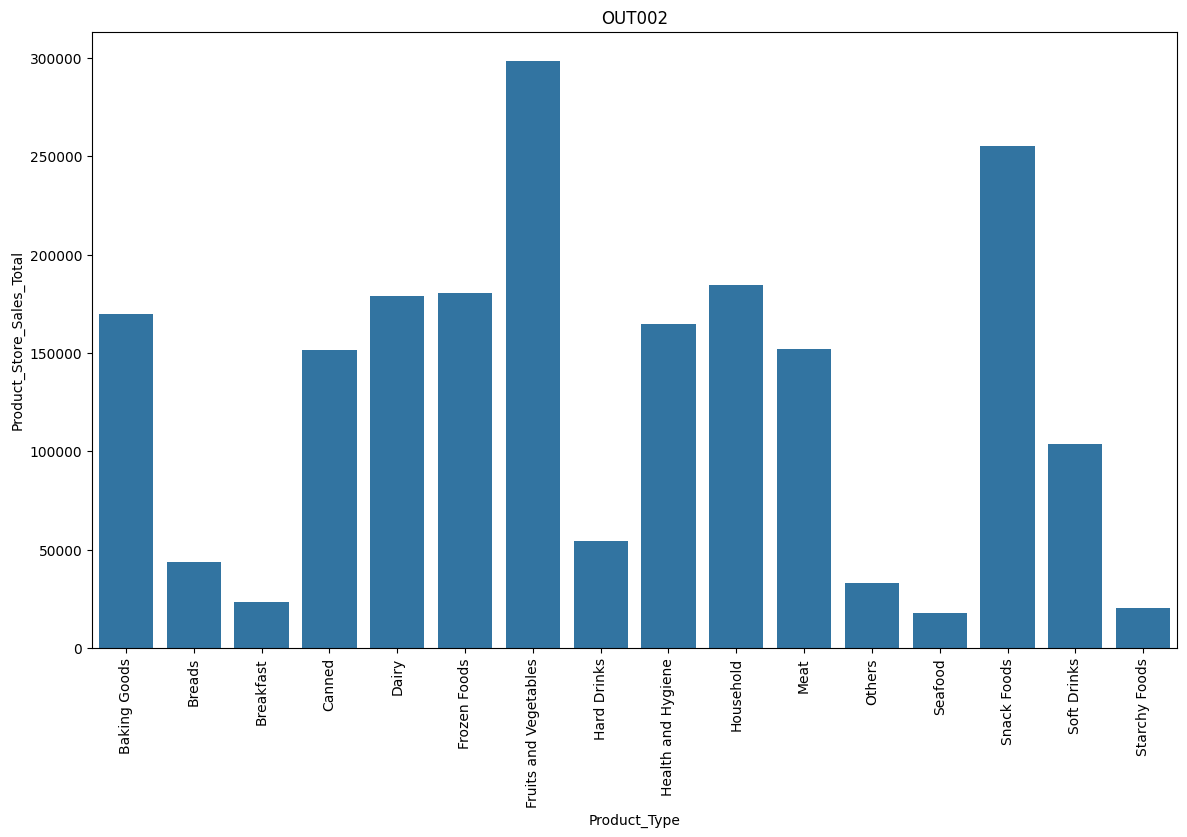

In [51]:
df_OUT002 = (
    data.loc[data["Store_Id"] == "OUT002"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT002")
sns.barplot(x=df_OUT002.Product_Type, y=df_OUT002.Product_Store_Sales_Total)
plt.show()

- OUT002 has generated the highest revenue from the sale of fruits and vegetables (~ 300000) followed by snack foods (~ 250000).

#### OUT003

In [52]:
data.loc[data["Store_Id"] == "OUT003"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1349,1349,NC522,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1349.0,NaN,NaN,NaN,15.103692,1.893531,7.35,14.02,15.18,16.35,22.0
Product_Sugar_Content,1349,4,Low Sugar,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1349.0,NaN,NaN,NaN,0.068637,0.048708,0.004,0.031,0.057,0.094,0.298
Product_Type,1349,16,Snack Foods,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1349.0,NaN,NaN,NaN,181.358725,24.796429,85.88,166.92,179.67,198.07,266.0
Store_Id,1349,1,OUT003,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1349.0,NaN,NaN,NaN,1999.0,0.0,1999.0,1999.0,1999.0,1999.0,1999.0
Store_Size,1349,1,Medium,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1349,1,Tier 1,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT003 is a Departmental store which is located in a Tier 1 city and has store size as medium. It was established in 1999.
- OUT003 has sold products whose MRP range from 86 to 266.
- Snack Foods have been sold the highest number of times in OUT003.
- The revenue generated from each product at OUT003 ranges from 3070 to 8000.

In [53]:
data.loc[data["Store_Id"] == "OUT003", "Product_Store_Sales_Total"].sum()

np.float64(6673457.57)

- OUT003 has generated total revenue of $6,673,458 from the sales of goods.

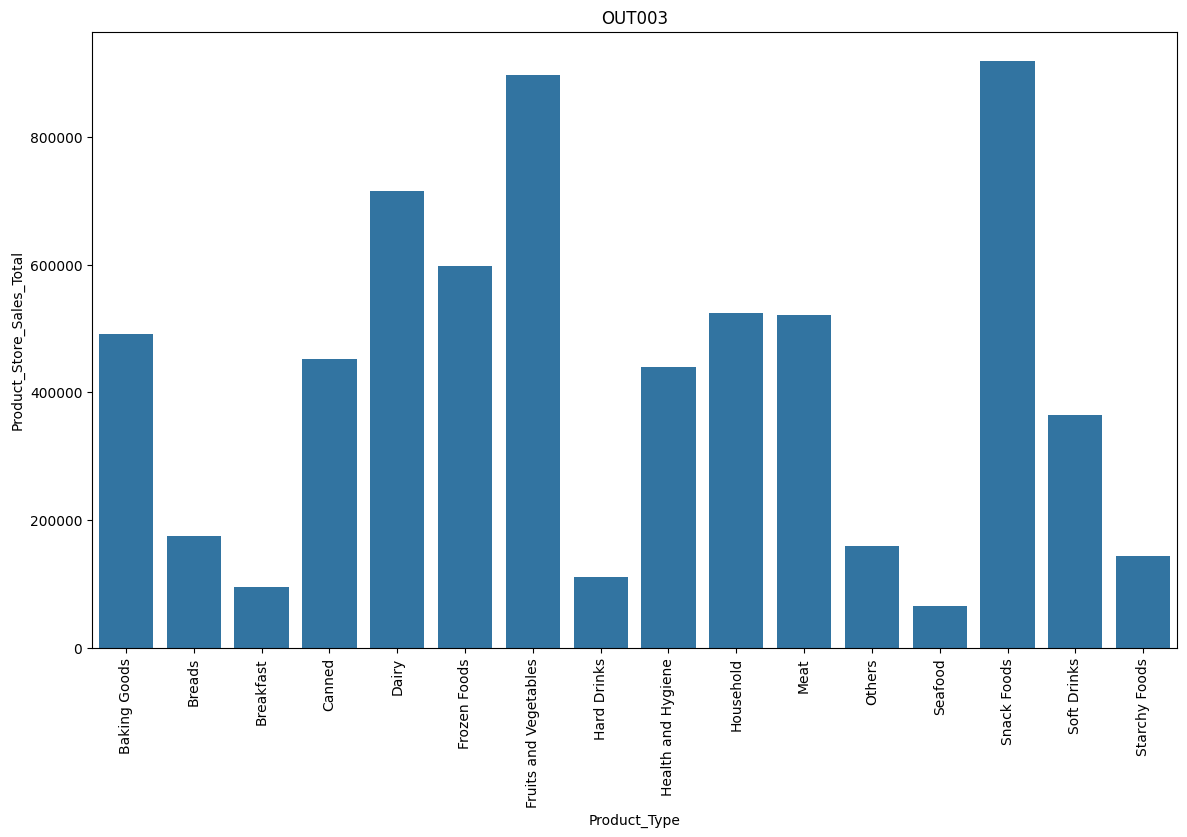

In [54]:
df_OUT003 = (
    data.loc[data["Store_Id"] == "OUT003"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT003")
sns.barplot(x=df_OUT003.Product_Type, y=df_OUT003.Product_Store_Sales_Total)
plt.show()

- OUT003 has generated the highest revenue from the sale of snack foods followed by fruits and vegetables, both the categories contributing around 800000 each.

#### OUT004

In [55]:
data.loc[data["Store_Id"] == "OUT004"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,4676,4676,NC584,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,4676.0,NaN,NaN,NaN,12.349613,1.428199,7.34,11.37,12.37,13.3025,17.79
Product_Sugar_Content,4676,4,Low Sugar,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,4676.0,NaN,NaN,NaN,0.069092,0.048584,0.004,0.031,0.056,0.097,0.297
Product_Type,4676,16,Fruits and Vegetables,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,4676.0,NaN,NaN,NaN,142.399709,17.513973,83.04,130.54,142.82,154.1925,197.66
Store_Id,4676,1,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,4676.0,NaN,NaN,NaN,2009.0,0.0,2009.0,2009.0,2009.0,2009.0,2009.0
Store_Size,4676,1,Medium,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,4676,1,Tier 2,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT004 is a store of Supermarket Type2 which is located in a Tier 2 city and has store size as medium. It was established in 2009.
- OUT004 has sold products whose MRP range from 83 to 198.
- Fruits and vegetables have been sold the highest number of times in OUT004.
- The revenue generated from each product at OUT004 ranges from 1561 to 5463.

In [56]:
data.loc[data["Store_Id"] == "OUT004", "Product_Store_Sales_Total"].sum()

np.float64(15427583.43)

- OUT004 has generated total revenue of $1,542,7583 from the sales of goods which is highest among all the 4 stores.

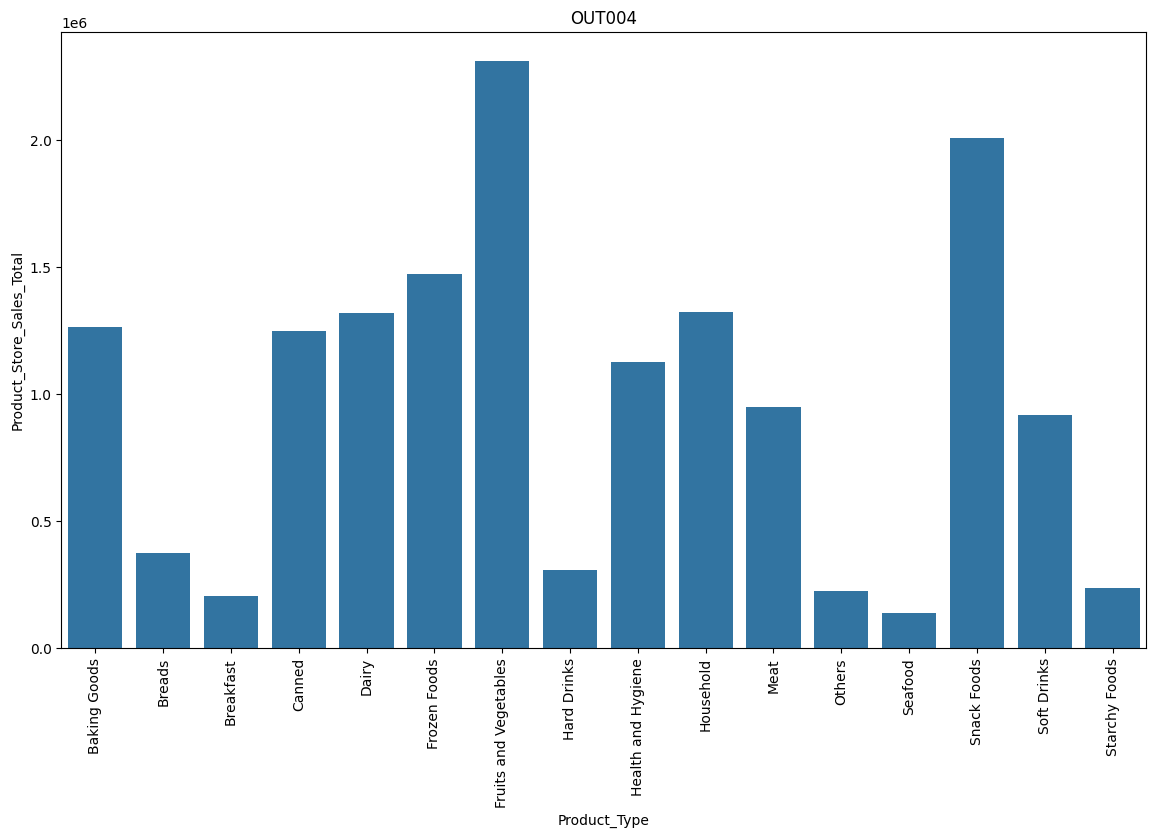

In [57]:
df_OUT004 = (
    data.loc[data["Store_Id"] == "OUT004"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT004")
sns.barplot(x=df_OUT004.Product_Type, y=df_OUT004.Product_Store_Sales_Total)
plt.show()

- OUT004 has generated the highest revenue from the sale of fruits and vegetables (~ 2500000) followed by snack foods (~ 2000000).

####**Let's find out the revenue generated by the stores from each of the product types**.

In [58]:
df1 = data.groupby(["Product_Type", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df1

,Product_Type,Store_Id,Product_Store_Sales_Total
0,Baking Goods,OUT001,525131.04
1,Baking Goods,OUT002,169860.50
2,Baking Goods,OUT003,491908.20
3,Baking Goods,OUT004,1266086.26
4,Breads,OUT001,121274.09
5,Breads,OUT002,43419.47
6,Breads,OUT003,175391.93
7,Breads,OUT004,374856.75
8,Breakfast,OUT001,38161.10
9,Breakfast,OUT002,23396.10


- In all the product types, the revenue generated by OUT004 has been the highest which seems quite logical since around 53% of the total products were brought from this store.
- In all the product categories, the revenue generated by OUT002 has been the lowest which seems quite obvious since it is small store in a Tier 3 city.

####**Let's find out the revenue generated by the stores from products having different levels of sugar content**.

In [59]:
df2 = data.groupby(["Product_Sugar_Content", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df2

,Product_Sugar_Content,Store_Id,Product_Store_Sales_Total
0,Low Sugar,OUT001,3300834.93
1,Low Sugar,OUT002,1156758.85
2,Low Sugar,OUT003,3706903.24
3,Low Sugar,OUT004,8658908.78
4,No Sugar,OUT001,1090353.78
5,No Sugar,OUT002,382162.19
6,No Sugar,OUT003,1123084.57
7,No Sugar,OUT004,2674343.14
8,Regular,OUT001,1749444.51
9,Regular,OUT002,472112.50


- The trend is the same as that which was present in the revenue analysis of stores for product types.

# **Data Preprocessing**

## **Replacing the values in the Product_Sugar_Content column**

We can observe that in the Product_Sugar_Content column, there are 3 types - Low Sugar, Regular and reg.

It seems quite obvious that Regular and reg are referring to the same category. So let's replace reg with Regular.

In [60]:
# Replacing reg with Regular
data.Product_Sugar_Content.replace(to_replace=["reg"], value=["Regular"], inplace=True)

In [61]:
data.Product_Sugar_Content.value_counts()

,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


## **Exploring Patterns in Product_IDs**

We can see that the Product_Id column has two characters followed by a number.

Let's delve deeper and see whether they are having any relationship with the other columns or not

In [62]:
## extracting the first two characters from the Product_Id column and storing it in another column
data["Product_Id_char"] = data["Product_Id"].str[:2]
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC


In [63]:
data["Product_Id_char"].unique()

array(['FD', 'NC', 'DR'], dtype=object)

In [64]:
data.loc[data.Product_Id_char == "FD", "Product_Type"].unique()

array(['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods',
       'Meat', 'Fruits and Vegetables', 'Breads', 'Breakfast',
       'Starchy Foods', 'Seafood'], dtype=object)

- Seems FD in Product Id refers to Food category.
- 11 types of products present in Food cateogry

In [65]:
data.loc[data.Product_Id_char == "DR", "Product_Type"].unique() #Select the rows where Product_Id_char is DR

array(['Hard Drinks', 'Soft Drinks'], dtype=object)

- DR stands for drinks category and there are two product types in Drinks category.

In [66]:
data.loc[data.Product_Id_char == "NC", "Product_Type"].unique() #Select the rows where Product_Id_char is NC

array(['Health and Hygiene', 'Household', 'Others'], dtype=object)

- NC seems to represent Non-consumable and has about 3 product types.

## **Store's Age**

A store which has been in the business for a long duration is more trustworthy than the newly established ones.

On the other hand, older stores may sometimes lack infrastructure if proper attention is not given. So let us calculate the current age of the store and incorporate that in our model.

In [67]:
# Outlet Age
data["Store_Age_Years"] = 2025 - data.Store_Establishment_Year
data["Store_Age_Years"].unique()

array([16, 26, 38, 27])

## **Grouping Product Types into Perishables and Non-Perishables.**

We have 16 different product types in our dataset.

So let us make two broad categories, perishables and non perishables, in order to reduce the number of product types

In [68]:
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

In [69]:
def change(x):
    if x in perishables:
        return "Perishables"
    else:
        return "Non Perishables"

In [70]:
data['Product_Type_Category'] = data['Product_Type'].apply(change)

In [71]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


## **Outlier Check**

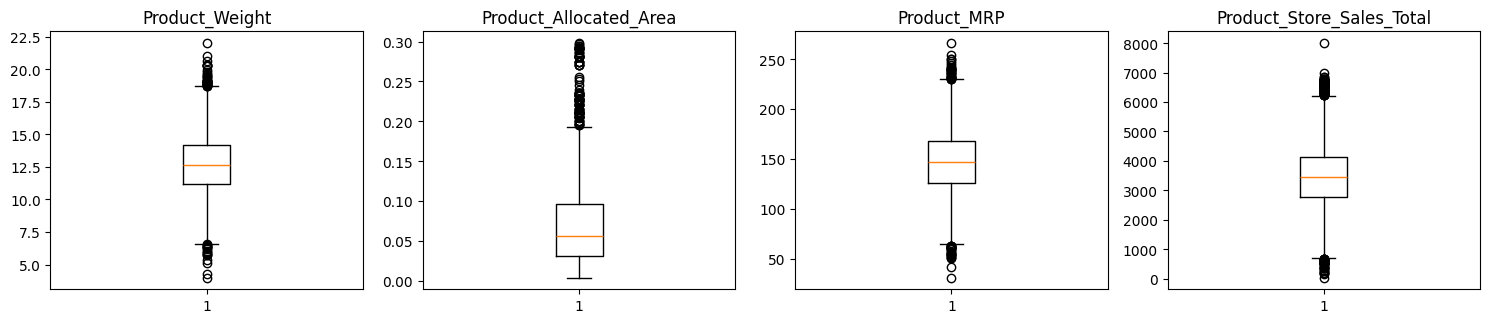

In [72]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("Store_Establishment_Year")
numeric_columns.remove("Store_Age_Years")


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

## **Data Preparation for Modeling**

- We aim to forecast the Product_Store_Sales_Total.

- Before building the model, we'll drop unnecessary columns and encode the categorical features.

- We'll then split the data into training and testing sets to evaluate the model's performance on unseen data.

In [73]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


Let's remove the columns that are not required.

In [74]:
data = data.drop(["Product_Id", "Product_Type", "Store_Id", "Store_Establishment_Year"], axis=1) #Drop the columns "Product_Id","Product_Type","Store_Id","Store_Establishment_Year"

In [75]:
data.shape

(8763, 11)

In [76]:
data.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


In [77]:
# Separating features and the target column
X = data.drop("Product_Store_Sales_Total", axis=1)
y = data["Product_Store_Sales_Total"]

In [78]:
# Splitting the data into train and test sets in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, shuffle=True)

In [79]:
X_train.shape, X_test.shape

((6134, 10), (2629, 10))

In [80]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6134 entries, 910 to 235
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Product_Weight            6134 non-null   float64
 1   Product_Sugar_Content     6134 non-null   object 
 2   Product_Allocated_Area    6134 non-null   float64
 3   Product_MRP               6134 non-null   float64
 4   Store_Size                6134 non-null   object 
 5   Store_Location_City_Type  6134 non-null   object 
 6   Store_Type                6134 non-null   object 
 7   Product_Id_char           6134 non-null   object 
 8   Store_Age_Years           6134 non-null   int64  
 9   Product_Type_Category     6134 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 527.1+ KB


In [81]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 6134 entries, 910 to 235
Series name: Product_Store_Sales_Total
Non-Null Count  Dtype  
--------------  -----  
6134 non-null   float64
dtypes: float64(1)
memory usage: 95.8 KB


### **Data Pre-processing Pipeline**

In [82]:
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features

['Product_Sugar_Content',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type',
 'Product_Id_char',
 'Product_Type_Category']

In [83]:
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()
numerical_features

['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age_Years']

In [84]:
# Create a preprocessing pipeline for the categorical features
from sklearn.impute import SimpleImputer


preprocessor = make_column_transformer(
    (Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features),
    (Pipeline([('num_imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())]), numerical_features)
 )



preprocessor

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Product_Sugar_Content', 'Store_Size',
                                  'Store_Location_City_Type', 'Store_Type',
                                  'Product_Id_char', 'Product_Type_Category']),
                                ('pipeline-2',
                                 Pipeline(steps=[('num_imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Product_Weight', 'Product_Allocated_Area',
                                  'Product_MRP', 'Store_Age_Years'])])

# **Model Building**

<h2><b>Note: As per the rubric, you are required to build two ML models for this project. We have provided the code required for model building for six different ML models, each under a separate markdown section.  You may choose any two models from the ones provided below, uncomment the corresponding code for the model, and then run the code to build the model, and check its performance.</b></h2>

## Define functions for Model Evaluation

- We'll fit different models on the train data and observe their performance.
- We'll try to improve that performance by tuning some hyperparameters available for that algorithm.
- We'll use GridSearchCv for hyperparameter tuning and `r_2 score` to optimize the model.
- R-square - `Coefficient of determination` is used to evaluate the performance of a regression model. It is the amount of the variation in the output dependent attribute which is predictable from the input independent variables.
- Let's start by creating a function to get model scores, so that we don't have to use the same codes repeatedly.

In [85]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

## Decision Tree Model

In [86]:
# Decision tree regressor is to be used

#dtree = DecisionTreeRegressor(random_state=1)
#dtree = make_pipeline(preprocessor,dtree)
#dtree.fit(X_train, y_train)

### Checking model performance on training set

In [87]:
# Decision tree regressor is to be used

#dtree_model_train_perf = model_performance_regression(dtree, X_train, y_train)
#dtree_model_train_perf

### Checking model performance on test set

In [88]:
# Decision tree regressor is to be used

#dtree_model_test_perf = model_performance_regression(dtree, X_test, y_test)
#dtree_model_test_perf

## Bagging Regressor

In [89]:
# Baggingregressor is to be used

#bagging_regressor = BaggingRegressor(random_state=1)
#bagging_regressor = make_pipeline(preprocessor,bagging_regressor)
#bagging_regressor.fit(X_train, y_train)

### Checking model performance on training set

In [90]:
#bagging_regressor_model_train_perf = model_performance_regression(bagging_regressor, X_train, y_train)
#bagging_regressor_model_train_perf

### Checking model performance on test set

In [91]:
#bagging_regressor_model_test_perf = model_performance_regression(bagging_regressor, X_test, y_test)
#bagging_regressor_model_test_perf

## Random Forest Model

In [92]:
# Random forest regressor

rf_estimator = RandomForestRegressor(random_state=1)
rf_estimator = make_pipeline(preprocessor,rf_estimator)
rf_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=1))])

### Checking model performance on training set

In [93]:
rf_estimator_model_train_perf = model_performance_regression(rf_estimator, X_train, y_train)
rf_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,104.588141,39.957071,0.990333,0.990317,0.014119


### Checking model performance on test set

In [94]:
rf_estimator_model_test_perf = model_performance_regression(rf_estimator, X_test, y_test)
rf_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,295.708332,112.423789,0.923587,0.923295,0.050145


## AdaBoost Regressor

In [95]:
# Adaboost regressor

#ab_regressor = AdaBoostRegressor(random_state=1)
#ab_regressor = make_pipeline(preprocessor,ab_regressor)
#ab_regressor.fit(X_train, y_train)

### Checking model performance on training set

In [96]:
#ab_regressor_model_train_perf = model_performance_regression(ab_regressor, X_train, y_train)
#ab_regressor_model_train_perf

### Checking model performance on test set

In [97]:
#ab_regressor_model_test_perf = model_performance_regression(ab_regressor, X_test, y_test)
#ab_regressor_model_test_perf

## Gradient Boosting Regressor

In [98]:
# #Gradientboost regressor

# gb_estimator = GradientBoostingRegressor(random_state=1)
# gb_estimator = make_pipeline(preprocessor,gb_estimator)
# gb_estimator.fit(X_train, y_train)

### Checking model performance on training set

In [99]:
# gb_estimator_model_train_perf = model_performance_regression(gb_estimator, X_train, y_train)
# gb_estimator_model_train_perf

### Checking model performance on test set

In [100]:
# gb_estimator_model_test_perf = model_performance_regression(gb_estimator, X_test, y_test)
# gb_estimator_model_test_perf

## XGBoost Regressor

In [101]:
# xgboost regressor

xgb_estimator = XGBRegressor(random_state=1)
xgb_estimator = make_pipeline(preprocessor,xgb_estimator)
xgb_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median'...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

### Checking model performance on training set

In [102]:
xgb_estimator_model_train_perf = model_performance_regression(xgb_estimator, X_train, y_train)
xgb_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,118.628943,58.099567,0.987563,0.987542,0.019789


### Checking model performance on test set

In [103]:
xgb_estimator_model_test_perf = model_performance_regression(xgb_estimator, X_test, y_test)
xgb_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,309.448421,138.03274,0.916321,0.916001,0.056671


# **Model Performance Improvement - Hyperparameter Tuning**

<h2><b>Note:</b></h2>

<h2><b>1. As per the rubric, you are required to tune two ML models for this project. We have provided the code required for model building for six different ML models, each under a separate markdown section.  You may choose the two models you built previously, uncomment the corresponding code for the model, and then run the code to tune the model, and check its performance.</b></h2>
<h2><b>2. We've provided a sample parameter grid for tuning. You may add/remove parameters or parameter values to check for during tuning as per your requirements.</b></h2>

## Hyperparameter Tuning - Decision Tree

In [104]:

# # # Choose the type of classifier.
# dtree_tuned = DecisionTreeRegressor(random_state=1)
# dtree_tuned = make_pipeline(preprocessor,dtree_tuned)

# # # Grid of parameters to choose from
# parameters = {
#     "decisiontreeregressor__max_depth": list(np.arange(2, 6)),
#     "decisiontreeregressor__min_samples_leaf": [1, 3, 5],
#     "decisiontreeregressor__max_leaf_nodes": [2, 3, 5, 10, 15],
#     "decisiontreeregressor__min_impurity_decrease": [0.001, 0.01, 0.1],
# }

# # # Run the grid search
# grid_obj = GridSearchCV(dtree_tuned, parameters, scoring=r2_score, cv=5, n_jobs =-1)
# grid_obj = grid_obj.fit(X_train, y_train)

# # # Set the clf to the best combination of parameters
# dtree_tuned = grid_obj.best_estimator_

# # # Fit the best algorithm to the data.
# dtree_tuned.fit(X_train, y_train)

### Checking model performance on training set

In [105]:
# dtree_tuned_model_train_perf = model_performance_regression(dtree_tuned, X_train, y_train)
# dtree_tuned_model_train_perf

### Checking model performance on test set

In [106]:
# dtree_tuned_model_test_perf = model_performance_regression(dtree_tuned, X_test, y_test)
# dtree_tuned_model_test_perf

## Hyperparameter Tuning - Bagging Regressor

In [107]:
# # # Choose the type of regressor.
# bagging_estimator_tuned = BaggingRegressor(random_state=1)
# bagging_estimator_tuned = make_pipeline(preprocessor,bagging_estimator_tuned)

# # # Grid of parameters to choose from
# parameters = {
#     "baggingregressor__max_samples": [0.5, 0.7, 0.9, 1.0],
#     "baggingregressor__max_features": [ 0.5, 0.7, 0.9, 1.0],
#     "baggingregressor__n_estimators": [100, 150, 200, 75],
# }

# # # Run the grid search
# grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring=r2_score, cv=5, n_jobs = -1)
# grid_obj = grid_obj.fit(X_train, y_train)

# # # Set the clf to the best combination of parameters
# bagging_estimator_tuned = grid_obj.best_estimator_

# # # Fit the best algorithm to the data.
# bagging_estimator_tuned.fit(X_train, y_train)

### Checking model performance on training set

In [108]:
# bagging_estimator_tuned_model_train_perf = model_performance_regression(bagging_estimator_tuned, X_train, y_train)
# bagging_estimator_tuned_model_train_perf

### Checking model performance on test set

In [109]:
# bagging_estimator_tuned_model_test_perf = model_performance_regression(bagging_estimator_tuned, X_test, y_test)
# bagging_estimator_tuned_model_test_perf

## Hyperparameter Tuning - Random Forest

In [110]:
# rf_tuned = RandomForestRegressor(random_state=1)
# rf_tuned = make_pipeline(preprocessor,rf_tuned)

# # # Grid of parameters to choose from
# parameters = {
#     "randomforestregressor__max_depth":  [3, 5, 7, 10, 15, None],
#     "randomforestregressor__max_features": [ 0.5, 0.7, 0.9, 1.0],
#     "randomforestregressor__n_estimators": [75, 100, 150, 200, 300],
#     "randomforestregressor__min_samples_split": [2, 5, 10],
# }

# # # Run the grid search
# grid_obj = GridSearchCV(rf_tuned, parameters, scoring=r2_score, cv=5, n_jobs = -1)
# grid_obj = grid_obj.fit(X_train, y_train)

# # # Set the clf to the best combination of parameters
# rf_tuned = grid_obj.best_estimator_

# # # Fit the best algorithm to the data.
# rf_tuned.fit(X_train, y_train)

In [111]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

rf_tuned = RandomForestRegressor(random_state=1)
rf_tuned = make_pipeline(preprocessor, rf_tuned)

# Parameter distributions instead of fixed grid
parameters = {
    "randomforestregressor__max_depth": [3, 5, 7, 10, 15, None],
    "randomforestregressor__max_features": uniform(0.5, 0.5),  # samples between 0.5-1.0
    "randomforestregressor__n_estimators": randint(75, 300),
    "randomforestregressor__min_samples_split": randint(2, 10),
}

# RandomizedSearchCV - replacement for GridSearchCV
grid_obj = RandomizedSearchCV(
    rf_tuned,
    parameters,
    n_iter=50,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)
grid_obj = grid_obj.fit(X_train, y_train)

# Set to best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
rf_tuned.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=10,
                                       max_features=np.float64(0.9018360384495572),
                                       min_samples_split=5, n_estimators=158,
                                       random_state=1))])

### Checking model performance on training set

In [112]:
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
rf_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,196.951309,79.565829,0.965718,0.965662,0.027084


### Checking model performance on test set

In [113]:
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
rf_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,288.939748,114.47775,0.927045,0.926766,0.051438


## Hyperparameter Tuning - AdaBoost Regressor

In [114]:
# ab_tuned = AdaBoostRegressor(random_state=1)
# ab_tuned = make_pipeline(preprocessor,ab_tuned)
# # # Grid of parameters to choose from
# parameters = {
#     "adaboostregressor__n_estimators": [100, 150, 200, 75],
#     "adaboostregressor__learning_rate": [0.01, 0.25, 0.5, 0.75, 1],
# }


# # # Run the grid search
# grid_obj = GridSearchCV(ab_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
# grid_obj = grid_obj.fit(X_train, y_train)

# # # Set the clf to the best combination of parameters
# ab_tuned = grid_obj.best_estimator_

# # # Fit the best algorithm to the data.
# ab_tuned.fit(X_train, y_train)

### Checking model performance on training set

In [115]:
# ab_tuned_model_train_perf = model_performance_regression(ab_tuned, X_train, y_train)
# ab_tuned_model_train_perf

### Checking model performance on test set

In [116]:
# ab_tuned_model_test_perf = model_performance_regression(ab_tuned, X_test, y_test)
# ab_tuned_model_train_perf

## Hyperparameter Tuning - Gradient Boosting Regressor

In [117]:
# gb_tuned = GradientBoostingRegressor(random_state=1)
# gb_tuned = make_pipeline(preprocessor,gb_tuned)

# # Grid of parameters to choose from
# parameters = {
#     "gradientboostingregressor__n_estimators": [100, 150, 200, 75],
#     "gradientboostingregressor__subsample":[0.5,0.7,0.8],
#     "gradientboostingregressor__max_features": [ 0.5, 0.7, 0.9, 1.0],
#     "gradientboostingregressor__max_depth": [3,5,7],
# }


# # # Run the grid search
# grid_obj = GridSearchCV(gb_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
# grid_obj = grid_obj.fit(X_train, y_train)

# # Set the clf to the best combination of parameters
# gb_tuned = grid_obj.best_estimator_

# # Fit the best algorithm to the data.
# gb_tuned.fit(X_train, y_train)

### Checking model performance on training set

In [118]:
# gb_tuned_model_train_perf = model_performance_regression(gb_tuned, X_train, y_train)
# gb_tuned_model_train_perf

### Checking model performance on test set

In [119]:
# gb_tuned_model_test_perf = model_performance_regression(gb_tuned, X_test, y_test)
# gb_tuned_model_test_perf

## Hyperparameter Tuning - XGBoost Regressor

In [120]:
# xgb_tuned = XGBRegressor(random_state=1)
# xgb_tuned = make_pipeline(preprocessor,xgb_tuned)

# # Grid of parameters to choose from
# parameters = {
#     "xgbregressor__n_estimators": [100, 150, 200, 75],
#     "xgbregressor__subsample": [0.5,0.7,0.8],
#     "xgbregressor__gamma": [0, 0.1, 0.2, 0.5, 1, 5, 10],
#     "xgbregressor__colsample_bytree": [0.3, 0.5, 0.7, 0.9, 1.0],
#     "xgbregressor__colsample_bylevel": [0.5, 0.7, 0.9, 1.0],
# }

# # Run the grid search
# grid_obj = GridSearchCV(xgb_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
# grid_obj = grid_obj.fit(X_train, y_train)

# # Set the clf to the best combination of parameters
# xgb_tuned = grid_obj.best_estimator_

# # Fit the best algorithm to the data.
# xgb_tuned.fit(X_train, y_train)

In [121]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb_tuned = XGBRegressor(random_state=1)
xgb_tuned = make_pipeline(preprocessor, xgb_tuned)

# Parameter distributions instead of fixed grid
parameters = {
    "xgbregressor__n_estimators": randint(75, 300),
    "xgbregressor__subsample": uniform(0.5, 0.5),        # samples between 0.5-1.0
    "xgbregressor__gamma": uniform(0, 10),                # samples between 0-10
    "xgbregressor__colsample_bytree": uniform(0.3, 0.7), # samples between 0.3-1.0
    "xgbregressor__colsample_bylevel": uniform(0.5, 0.5),# samples between 0.5-1.0
    "xgbregressor__learning_rate": uniform(0.01, 0.3),   # bonus param - helps a lot!
    "xgbregressor__max_depth": randint(3, 10),            # bonus param - controls overfitting
}

# RandomizedSearchCV
grid_obj = RandomizedSearchCV(
    xgb_tuned,
    parameters,
    n_iter=50,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    random_state=42,    # reproducibility
    verbose=2           # track progress
)
grid_obj = grid_obj.fit(X_train, y_train)

# Set to best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
xgb_tuned.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median'...
                              grow_policy=None, importance_type=None,
                              interaction_constraints=None,
                              learning_rate=np.float64(0.092799754606763),
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=89, n_jobs=None,
                              num_parallel_tree=None, ...))])

### Checking model performance on training set

In [122]:
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,187.656987,78.993546,0.968877,0.968826,0.02743


### Checking model performance on test set

In [123]:
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
xgb_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,294.965026,119.734035,0.923971,0.92368,0.05183


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [124]:
 # training performance comparison

models_train_comp_df = pd.concat(
    [
        rf_estimator_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        xgb_estimator_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
        ],
    axis=1,
)

models_train_comp_df.columns = ["Random Forest Regressor",
                                "Random Forest Regressor - Tuned",
                                "XGBoost Regressor",
                                "XGBoost Regressor - Tuned",
                                ]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Random Forest Regressor,Random Forest Regressor - Tuned,XGBoost Regressor,XGBoost Regressor - Tuned
RMSE,104.588141,196.951309,118.628943,187.656987
MAE,39.957071,79.565829,58.099567,78.993546
R-squared,0.990333,0.965718,0.987563,0.968877
Adj. R-squared,0.990317,0.965662,0.987542,0.968826
MAPE,0.014119,0.027084,0.019789,0.027430


In [125]:
 # test performance comparison

models_test_comp_df = pd.concat(
    [
        rf_estimator_model_test_perf.T,
        rf_tuned_model_test_perf.T,
        xgb_estimator_model_test_perf.T,
        xgb_tuned_model_test_perf.T,
        ],
    axis=1,
)

models_test_comp_df.columns = ["Random Forest Regressor",
                                "Random Forest Regressor - Tuned",
                                "XGBoost Regressor",
                                "XGBoost Regressor - Tuned",
                                ]

print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Random Forest Regressor,Random Forest Regressor - Tuned,XGBoost Regressor,XGBoost Regressor - Tuned
RMSE,295.708332,288.939748,309.448421,294.965026
MAE,112.423789,114.477750,138.032740,119.734035
R-squared,0.923587,0.927045,0.916321,0.923971
Adj. R-squared,0.923295,0.926766,0.916001,0.923680
MAPE,0.050145,0.051438,0.056671,0.051830


In [126]:
(models_train_comp_df - models_test_comp_df).iloc[2]

,R-squared
Random Forest Regressor,0.066746
Random Forest Regressor - Tuned,0.038673
XGBoost Regressor,0.071242
XGBoost Regressor - Tuned,0.044907


- On training data, Random Forest, XGBoost and Tuned XGBoost all performed really well with an R-squared values above 0.94.
- Looking at the training and test results, Random Forest and XGBoost models achieved highest Adjusted R-squared values, indicating that they predicted sales well on seen as well unseen data.
- Tuned Random Forest regressor has the lowest R-squared difference between the training and test data, which means its the most consistent and less overfitting model. But its overall accuracy is not competitive enough for it be considered as a best model.
- Based on the observations, the best model is Random Forest Regressor. It has done well on the unseen data and is the strongest of all.

In [127]:
best_model = rf_tuned
best_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=10,
                                       max_features=np.float64(0.9018360384495572),
                                       min_samples_split=5, n_estimators=158,
                                       random_state=1))])

# Model Serilization

In [128]:
# Create a folder for storing the deployment files.
os.makedirs("backend_files", exist_ok=True)

In [129]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "backend_files/SuperKart_Model_v1.joblib"

In [130]:
# Save the best trained model pipeline using joblib
joblib.dump(best_model, saved_model_path)

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at backend_files/SuperKart_Model_v1.joblib


In [131]:
# Load the saved model pipeline from the file
saved_model = joblib.load("backend_files/SuperKart_Model_v1.joblib")

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [132]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=10,
                                       max_features=np.float64(0.9018360384495572),
                                       min_samples_split=5, n_estimators=158,
                                       random_state=1))])

Let's try making predictions on the test set using the deserialized model.

- Please ensure that the saved model is loaded before making predictions.

In [133]:
saved_model.predict(X_test)

array([3709.72534256, 5853.6653369 , 4456.48756815, ..., 3100.00114172,
       3172.56507711, 3554.83223897])

- As we can see, the model can be directly used for making predictions without any retraining.

# **Deployment - Backend**

## Flask Web Framework


In [134]:
%%writefile backend_files/app.py

# Import necessary libraries
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API

# Initialize Flask app with a name
superkart_api = Flask("SuperKart")

# Load the trained churn prediction model
model = joblib.load("SuperKart_Model_v1.joblib")

# Define a route for the home page
@superkart_api.get('/')
def home():
    return "Welcome to SuperKart API - A place to do some kool predictions :)"

# Define an endpoint to predict churn for a single customer
@superkart_api.post('/v1/predict')
def predict_sales():
    # Get JSON data from the request
    data = request.get_json()

    # Extract relevant customer features from the input data. The order of the column names matters.
    sample = {
        'Product_Weight': data['Product_Weight'],
        'Product_Sugar_Content': data['Product_Sugar_Content'],
        'Product_Allocated_Area': data['Product_Allocated_Area'],
        'Product_MRP': data['Product_MRP'],
        'Store_Size': data['Store_Size'],
        'Store_Location_City_Type': data['Store_Location_City_Type'],
        'Store_Type': data['Store_Type'],
        'Product_Id_char': data['Product_Id_char'],
        'Store_Age_Years': data['Store_Age_Years'],
        'Product_Type_Category': data['Product_Type_Category']
    }

    # Convert the extracted data into a DataFrame
    input_data = pd.DataFrame([sample])

    # Make a churn prediction using the trained model
    prediction = model.predict(input_data).tolist()[0]

    # Return the prediction as a JSON response
    return jsonify({'Sales': prediction})


# Run the Flask app in debug mode
if __name__ == '__main__':
    superkart_api.run(debug=True)

Writing backend_files/app.py


## Dependencies File

In [135]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
seaborn==0.13.2
joblib==1.4.2
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.32.3
uvicorn[standard]
streamlit==1.43.2

Writing backend_files/requirements.txt


## Dockerfile

In [136]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app #Complete the code to mention the command in Docker to set the working directory

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]

Writing backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

**Note**: We are creating a Hugging Face Docker Space for our backend using the Hugging Face Hub API. This automates the space creation process and enables seamless deployment of our Flask app.

In [137]:
# Import the login function from the huggingface_hub library
from huggingface_hub import login
from google.colab import userdata
token = userdata.get('SK_HF_TOKEN')

# Login to your Hugging Face account using your access token
# Replace "YOUR_HUGGINGFACE_TOKEN" with your actual token
#login(token="YOUR_HUGGINGFACE_TOKEN")  # You can get your token from https://huggingface.co/settings/tokens
login(token=token) #Complete the code to define the access token

# Import the create_repo function from the huggingface_hub library
from huggingface_hub import create_repo

In [138]:
# Try to create the repository for the Hugging Face Space
try:
    create_repo("superkart-sales-forecast-api",
        repo_type="space",  # Specify the repository type as "space"
        space_sdk="docker",  # Specify the space SDK as "docker"
        private=False  # Set to True if you want the space to be private
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

Error creating repository: Client error '409 Conflict' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-69ee30f2-4914f9bf1e5decda73ef3dc3;5aa4528f-c9c1-42df-9d01-a0a52db2d9a8)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/409

You already created this space repo: udx1/superkart-sales-forecast-api


## Uploading Files to Hugging Face Space (Docker Space)

**Note**: Before running the code below, ensure that the serialized ML model has been uploaded in to `backend_files` folder.

In [139]:
# for hugging face space authentication to upload files

access_key = token
repo_id = "udx1/superkart-sales-forecast-api"  # repo id.

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="backend_files",
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...SuperKart_Model_v1.joblib:  12%|#2        | 1.02MB / 8.23MB            

CommitInfo(commit_url='https://huggingface.co/spaces/udx1/superkart-sales-forecast-api/commit/33b6540fa3a747d672ee34a5c1e386f39b954747', commit_message='Upload folder using huggingface_hub', commit_description='', oid='33b6540fa3a747d672ee34a5c1e386f39b954747', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/udx1/superkart-sales-forecast-api', endpoint='https://huggingface.co', repo_type='space', repo_id='udx1/superkart-sales-forecast-api'), pr_revision=None, pr_num=None)

In [140]:
X_train.info()
#X_train.Store_Size.unique()

<class 'pandas.core.frame.DataFrame'>
Index: 6134 entries, 910 to 235
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Product_Weight            6134 non-null   float64
 1   Product_Sugar_Content     6134 non-null   object 
 2   Product_Allocated_Area    6134 non-null   float64
 3   Product_MRP               6134 non-null   float64
 4   Store_Size                6134 non-null   object 
 5   Store_Location_City_Type  6134 non-null   object 
 6   Store_Type                6134 non-null   object 
 7   Product_Id_char           6134 non-null   object 
 8   Store_Age_Years           6134 non-null   int64  
 9   Product_Type_Category     6134 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 527.1+ KB


# **Deployment - Frontend**

## Points to note before executing the below cells

- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

In [141]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [142]:
%%writefile frontend_files/app.py

import streamlit as st
import requests

st.title("SuperKart - Product Sales Predictions.") #Complete the code to define the title of the app.

# Input fields for product and store data
Product_Weight = st.number_input("Product Weight", min_value=0.0, value=12.66)
Product_Sugar_Content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
Product_Allocated_Area = st.number_input("Product Allocated Area", min_value=0.0)
Product_MRP = st.number_input("Product MRP", min_value=0.0)
Store_Size = st.selectbox("Store Size", ["Small", "Medium", "High"])
Store_Location_City_Type = st.selectbox("Store Location City Type", ['Tier 1', 'Tier 2', 'Tier 3'])
Store_Type = st.selectbox("Store Type", ['Departmental Store', 'Food Mart', 'Supermarket Type1', 'Supermarket Type2'])
Product_Id_char = st.selectbox("Product ID Char", ['DR', 'FD', 'NC'])
Store_Age_Years = st.number_input("Store Age Years", min_value=0.0)
Product_Type_Category = st.selectbox("Product Type Category", ['Non Perishables', 'Perishables'])

product_data = {
    "Product_Weight": Product_Weight,
    "Product_Sugar_Content": Product_Sugar_Content,
    "Product_Allocated_Area": Product_Allocated_Area,
    "Product_MRP": Product_MRP,
    "Store_Size": Store_Size,
    "Store_Location_City_Type": Store_Location_City_Type,
    "Store_Type": Store_Type,
    "Product_Id_char": Product_Id_char,
    "Store_Age_Years": Store_Age_Years,
    "Product_Type_Category": Product_Type_Category
}

if st.button("Predict", type='primary'):
    try:
        response = requests.post("https://udx1-superkart-sales-forecast-api.hf.space/v1/predict", json=product_data)
        if response.status_code == 200:
            result = response.json()
            predicted_sales = result["Sales"]
            st.write(f"Predicted Product Store Sales Total: ${predicted_sales:.2f}")
        else:
            st.error(f"Error {response.status_code}: {response.text}")
    except Exception as e:
        st.error(f"Something went wrong: {str(e)}")

Writing frontend_files/app.py


## Dependencies File

In [143]:
%%writefile frontend_files/requirements.txt
requests==2.32.3
streamlit==1.45.0

Writing frontend_files/requirements.txt


## Dockerfile

In [144]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Writing frontend_files/Dockerfile


## Uploading Files to Hugging Face Space (Streamlit Space)

In [145]:
access_key = token
repo_id = "udx1/superkart-sales-forecast"

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="frontend_files",
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/spaces/udx1/superkart-sales-forecast/commit/6511673795e2c9420eaf5722021fbb35995569f3', commit_message='Upload folder using huggingface_hub', commit_description='', oid='6511673795e2c9420eaf5722021fbb35995569f3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/udx1/superkart-sales-forecast', endpoint='https://huggingface.co', repo_type='space', repo_id='udx1/superkart-sales-forecast'), pr_revision=None, pr_num=None)

# **Actionable Insights and Business Recommendations**

- Further hyperparameter tuning with an expanded parameter grid could improve performance.
- Explore additional features such as seasonality, promotions, and regional economic indicators to improve accuracy
- Consider other models and ensemble approaches — combining Random Forest and XGBoost predictions may yield better results
- Implement automated retraining pipelines as new sales data becomes available to keep the model current
- Extend the Streamlit UI to support batch predictions via CSV upload for business users managing multiple stores
